# Deep Learning System: Steel Surface Defect Classification for Manufacturing Quality Inspection

This notebook is a graduate-level walkthrough of building an **image classification**
system using **transfer learning** with a convolutional neural network:

- **EfficientNetB0** — an ImageNet-pretrained CNN used as a frozen feature extractor, then fine-tuned
- **NEU Surface Defect Database (NEU-DET)** — grayscale images of hot-rolled steel strip surfaces

We use **manufacturing image data** to predict which of six surface defect types is present
on a steel surface.

---

### Why transfer learning?

Task 2a used tree ensembles on tabular patient records. Images are a different kind of
input: the "features" are not columns in a spreadsheet but spatial patterns of pixels.
Convolutional networks learn those features automatically — but they need far more data
than we have here.

| Property | Training a CNN from scratch | Transfer learning (this notebook) |
|----------|-----------------------------|-----------------------------------|
| Data required | Tens of thousands of images per class | Hundreds per class is workable |
| What is learned | All filters, from edges upward | Only a small classification head |
| Training time | Hours to days | Minutes on a single GPU |
| Overfitting risk | Very high on a small dataset | Much lower — most weights stay frozen |
| Starting point | Random weights | Visual features learned from 1.2M ImageNet images |

NEU-DET provides a few hundred images per class, which places it firmly in the
transfer-learning regime.

---

### Notebook roadmap

1. Environment setup (Google Colab **or** local Jupyter)
2. Inspect the original **NEU-DET** dataset
3. Create **train / validation / test** splits
4. Exploratory image analysis
5. Image preprocessing and data augmentation
6. Build TensorFlow dataset pipelines
7. **Transfer-learning model** — theory and architecture
8. Initial training (frozen backbone)
9. Fine-tuning (upper backbone unfrozen)
10. **Validation-based model selection**
11. **Final test evaluation**
12. Export model and evaluation artifacts
13. Inference on new / unseen images
14. Save prediction results
15. Gradio deployment demo
16. Manufacturing use case
17. Limitations and future improvements
18. Summary

> **Training vs inference:** Training uses *labeled* images — the folder name supplies the
> label — to learn what each defect looks like. Inference receives a *new* image with no
> label attached and produces a defect prediction that a quality inspector can act on.
> Section 13 reloads the saved model from disk to make that separation explicit.

---

### The three data splits

This notebook uses a strict **three-way split**, exactly as Task 2a did for tabular data:

| Split | Source | Role | Used for early stopping? | Used for final reporting? |
|---|---|---|---|---|
| **Train** | 80% of `NEU-DET/train/images` | Learn model parameters | No | No |
| **Validation** | 20% of `NEU-DET/train/images` | Early stopping, LR scheduling, model selection | **Yes** | No |
| **Test** | All of `NEU-DET/validation/images` | Final unbiased performance estimate | **Never** | **Yes** |

The headline numbers this notebook reports come from the **test set**, which is not touched
by any training or model-selection decision. Section 3 builds these splits and proves they
do not overlap.

---

### The six defect classes

| Class folder | Defect | Visual character |
|---|---|---|
| `crazing` | Crazing | A network of fine hairline cracks across the surface |
| `inclusion` | Inclusion | Foreign material rolled into the steel, often dark and elongated |
| `patches` | Patches | Irregular discoloured regions with diffuse edges |
| `pitted_surface` | Pitted Surface | Clusters of small cavities and pockmarks |
| `rolled-in_scale` | Rolled-in Scale | Oxide scale pressed into the metal during rolling |
| `scratches` | Scratches | Long, straight, directional gouges |

> **A note on the `annotations/` folders:** NEU-DET also ships XML bounding-box annotations
> alongside the images. This notebook performs **image-level classification**, so those files
> are not read — but they are left untouched on disk. Section 17 explains how they could
> support an object-detection extension that locates each defect rather than only naming it.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

---
## 1. Environment Setup

### Expected project structure

This notebook derives every path from a single project root, so the only thing you should
need to edit is `DRIVE_PROJECT_PATH`.

```
steel_defect_project/
├── data/
│   ├── NEU-DET/                 <- original download - NEVER modified
│   │   ├── train/
│   │   │   ├── images/          <- six class folders (source for train + validation)
│   │   │   └── annotations/     <- XML files (not used here)
│   │   └── validation/
│   │       ├── images/          <- six class folders (becomes the test set)
│   │       └── annotations/
│   ├── train/                   <- created by Section 3
│   ├── validation/              <- created by Section 3
│   └── test/                    <- created by Section 3
├── notebooks/
│   └── steel_surface_defect_deep_learning.ipynb   <- this file
└── artifacts/                   <- created by this notebook
    ├── model/
    ├── metrics/
    ├── plots/
    ├── metadata/
    └── predictions/
```

### Running on Google Colab

1. Upload the `steel_defect_project/` folder to Google Drive, keeping the structure intact.
   Only `data/NEU-DET/` needs to exist — the split folders and `artifacts/` are generated.
2. Open this notebook in Colab from Drive.
3. **Enable the GPU:** `Runtime → Change runtime type → Hardware accelerator → T4 GPU`.
4. Run the Colab setup cell below — it installs dependencies and mounts Drive.
5. Set `DRIVE_PROJECT_PATH` to where you uploaded the project.

### Running locally

From the project root, use Python 3.10–3.12:

```bash
python3.12 -m venv .venv
source .venv/bin/activate
pip install tensorflow numpy pandas matplotlib seaborn scikit-learn pillow gradio
jupyter notebook notebooks/steel_surface_defect_deep_learning.ipynb
```

Training on CPU works but is considerably slower than on a GPU.

### What gets created automatically

Only the **split** directories (`data/train`, `data/validation`, `data/test`) and the
**artifact** directories. The `data/NEU-DET/` download is never created, modified, moved or
deleted — it is read-only input. If it is missing, the validation cell raises an error
telling you exactly where to put it.

In [ ]:
# --- Colab-only setup (safe to run locally; it will no-op) ---
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q tensorflow numpy pandas matplotlib seaborn scikit-learn pillow
    from google.colab import drive
    drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/Manufacturing Surface Defect Detection/NEU-DET.zip" -d "/content/drive/MyDrive/Manufacturing Surface Defect Detection/data"
!ls "/content/drive/MyDrive/Manufacturing Surface Defect Detection/data/NEU-DET"


train  validation


In [ ]:
import hashlib
import json
import shutil
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)   # seeds Python, NumPy and TensorFlow together

# ------------------------------------------------------------------
# Path configuration - works on Google Colab AND locally
# ------------------------------------------------------------------

DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Manufacturing Surface Defect Detection"  # <-- edit for Colab

if IN_COLAB:
    PROJECT_ROOT = Path(DRIVE_PROJECT_PATH)
else:
    NOTEBOOK_DIR = Path.cwd()
    PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

# --- Original download: READ-ONLY. Never modified by this notebook. ---
RAW_DATASET_DIR = DATA_DIR / "NEU-DET"
RAW_TRAIN_DIR = RAW_DATASET_DIR / "train" / "images"
RAW_VALIDATION_DIR = RAW_DATASET_DIR / "validation" / "images"

# --- Generated splits: created by Section 3. ---
TRAIN_DIR = DATA_DIR / "train"
VALIDATION_DIR = DATA_DIR / "validation"
TEST_DIR = DATA_DIR / "test"

MODEL_DIR = ARTIFACTS_DIR / "model"
METRICS_DIR = ARTIFACTS_DIR / "metrics"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
METADATA_DIR = ARTIFACTS_DIR / "metadata"
PREDICTIONS_DIR = ARTIFACTS_DIR / "predictions"

# Only artifact directories are created here. The split folders are created in
# Section 3; the NEU-DET download must already exist.
for folder in [MODEL_DIR, METRICS_DIR, PLOTS_DIR, METADATA_DIR, PREDICTIONS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def save_fig(fig, filename: str, dpi: int = 130) -> Path:
    """Save a matplotlib figure into artifacts/plots/."""
    path = PLOTS_DIR / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved plot -> {path.relative_to(PROJECT_ROOT)}")
    return path


print(f"Running in Colab   : {IN_COLAB}")
print(f"Project root       : {PROJECT_ROOT.resolve()}")
print(f"Raw NEU-DET train  : {RAW_TRAIN_DIR.exists()}")
print(f"Raw NEU-DET val    : {RAW_VALIDATION_DIR.exists()}")
print(f"Artifacts dir      : {ARTIFACTS_DIR.resolve()}")

Running in Colab   : True
Project root       : /content/drive/MyDrive/Manufacturing Surface Defect Detection
Raw NEU-DET train  : True
Raw NEU-DET val    : True
Artifacts dir      : /content/drive/MyDrive/Manufacturing Surface Defect Detection/artifacts


In [ ]:
# ------------------------------------------------------------------
# Hardware check
# ------------------------------------------------------------------
# Deep learning on images is GPU-bound. This prints what is available so a slow
# run is never a surprise.

gpu_devices = tf.config.list_physical_devices("GPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")
print(f"Random seed:        {RANDOM_STATE}")
print("-" * 60)

if gpu_devices:
    for device in gpu_devices:
        print(f"GPU available: {device.name}")
    # Allocate GPU memory on demand rather than reserving the whole card up front.
    try:
        for device in gpu_devices:
            tf.config.experimental.set_memory_growth(device, True)
    except RuntimeError as err:
        print(f"(could not set memory growth: {err})")
else:
    print("No GPU detected - training will run on CPU and will be slow.")
    if IN_COLAB:
        print("Fix: Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU")

print("-" * 60)
print("Note on reproducibility: the seed above fixes the train/validation split,")
print("shuffling, augmentation draws and weight initialisation. GPU kernels remain")
print("non-deterministic, so metrics may vary slightly between runs.")

TensorFlow version: 2.20.0
Keras version:      3.13.2
Random seed:        42
------------------------------------------------------------
GPU available: /physical_device:GPU:0
------------------------------------------------------------
Note on reproducibility: the seed above fixes the train/validation split,
shuffling, augmentation draws and weight initialisation. GPU kernels remain
non-deterministic, so metrics may vary slightly between runs.


---
## 2. Inspect Original NEU-DET Dataset

Before creating any splits, we inspect the **original download** exactly as it arrived.
Nothing in `data/NEU-DET/` is modified, moved, renamed or deleted by this notebook — it is
treated as immutable raw input, the same way Task 2a treated its source CSV.

The download ships two folders, and Section 3 repurposes them:

| Original folder | Images | Becomes |
|---|---|---|
| `NEU-DET/train/images/` | Labelled, one folder per class | Split 80/20 into **train** and **validation** |
| `NEU-DET/validation/images/` | Labelled, one folder per class | Copied wholesale to **test** |

Everything below is **computed from the folders on disk**. No dataset statistic is
hard-coded, so these numbers describe your actual copy of the data.

In [ ]:
# ------------------------------------------------------------------
# Validate the original dataset location - fail loudly, never silently
# ------------------------------------------------------------------

import zipfile

EXPECTED_CLASSES = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches",
]

IMAGE_EXTENSIONS = (".bmp", ".jpg", ".jpeg", ".png")


def find_dataset_archive() -> Path | None:
    """Return a NEU-DET*.zip sitting in data/ or the project root, if there is one.

    Uploading a single archive is far quicker than uploading ~3,600 loose files
    to Drive, so the notebook accepts either form and unpacks the zip itself.
    """
    for folder in (DATA_DIR, PROJECT_ROOT):
        if folder.is_dir():
            for archive in sorted(folder.glob("NEU-DET*.zip")):
                return archive
    return None


def extract_dataset_archive(archive: Path) -> None:
    """Unpack the raw dataset into data/. The archive itself is left in place."""
    print(f"Raw dataset folders not found - unpacking {archive.name} ...")
    print(f"  archive     : {archive}")
    print(f"  destination : {DATA_DIR}")
    print("  (thousands of small files - on Google Drive this takes a few minutes)")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive) as bundle:
        bundle.extractall(DATA_DIR)
    print(f"Unpacked {archive.name}.\n")


def describe_missing_dataset() -> str:
    """Build an actionable error message when the raw dataset cannot be found."""
    lines = [
        "",
        "=" * 70,
        "ORIGINAL NEU-DET DATASET NOT FOUND",
        "=" * 70,
        f"Expected raw training images   : {RAW_TRAIN_DIR}",
        f"Expected raw validation images : {RAW_VALIDATION_DIR}",
        "",
        "Provide the dataset in either of these two forms.",
        "",
        "1. Extracted - place the downloaded folder so the structure looks like:",
        "",
        f"    {PROJECT_ROOT.name}/",
        "    └── data/",
        "        └── NEU-DET/",
        "            ├── train/",
        "            │   ├── images/          <- six class folders",
        "            │   └── annotations/",
        "            └── validation/",
        "                ├── images/          <- six class folders",
        "                └── annotations/",
        "",
        "2. Zipped - drop a NEU-DET*.zip into either of these and re-run this cell;",
        "   it is unpacked automatically:",
        "",
        f"       {DATA_DIR}",
        f"       {PROJECT_ROOT}",
        "",
    ]

    probe = PROJECT_ROOT if PROJECT_ROOT.exists() else Path.cwd()
    lines.append(f"Currently visible under {probe}:")
    if probe.exists():
        for item in sorted(probe.iterdir())[:25]:
            lines.append(f"    {item.name}{'/' if item.is_dir() else ''}")
    if DATA_DIR.exists():
        lines.append(f"\nContents of {DATA_DIR}:")
        for item in sorted(DATA_DIR.iterdir())[:25]:
            lines.append(f"    {item.name}{'/' if item.is_dir() else ''}")
    if RAW_DATASET_DIR.exists():
        lines.append(f"\nContents of {RAW_DATASET_DIR}:")
        for item in sorted(RAW_DATASET_DIR.iterdir())[:25]:
            lines.append(f"    {item.name}{'/' if item.is_dir() else ''}")

    lines += [
        "",
        "If your project lives elsewhere, edit DRIVE_PROJECT_PATH in Section 1.",
        "=" * 70,
    ]
    return "\n".join(lines)


# Unpack a zipped dataset automatically, then re-check. The raw folders are
# only ever created here - data/NEU-DET/ is never modified once it exists.
if not RAW_TRAIN_DIR.is_dir() or not RAW_VALIDATION_DIR.is_dir():
    dataset_archive = find_dataset_archive()
    if dataset_archive is not None:
        extract_dataset_archive(dataset_archive)

if not RAW_TRAIN_DIR.is_dir() or not RAW_VALIDATION_DIR.is_dir():
    raise FileNotFoundError(describe_missing_dataset())


def list_class_images(directory: Path) -> dict[str, list[Path]]:
    """Map each class folder to its sorted list of image files.

    Folders holding no images are ignored, so a stray `annotations` folder can
    never be mistaken for a seventh defect class. Sorting keeps the ordering
    deterministic, which matters for a reproducible split.
    """
    catalogue: dict[str, list[Path]] = {}
    for sub in sorted(p for p in directory.iterdir() if p.is_dir()):
        if sub.name.startswith("."):
            continue
        files = sorted(f for f in sub.iterdir()
                       if f.suffix.lower() in IMAGE_EXTENSIONS)
        if files:
            catalogue[sub.name] = files
    return catalogue


raw_train_catalogue = list_class_images(RAW_TRAIN_DIR)
raw_test_catalogue = list_class_images(RAW_VALIDATION_DIR)

# Verify the six expected classes are present in both original folders.
problems = []
for folder_label, catalogue in [("NEU-DET/train", raw_train_catalogue),
                                ("NEU-DET/validation", raw_test_catalogue)]:
    missing = set(EXPECTED_CLASSES) - set(catalogue)
    unexpected = set(catalogue) - set(EXPECTED_CLASSES)
    if missing:
        problems.append(f"{folder_label}: missing class folders {sorted(missing)}")
    if unexpected:
        problems.append(f"{folder_label}: unexpected class folders {sorted(unexpected)}")

if problems:
    raise ValueError(
        "Original dataset class folders do not match the expected NEU-DET layout:\n  - "
        + "\n  - ".join(problems)
        + f"\n\nExpected exactly: {EXPECTED_CLASSES}"
    )

CLASS_NAMES = sorted(raw_train_catalogue.keys())
NUM_CLASSES = len(CLASS_NAMES)

# Readable labels for plots, reports and the Gradio app.
DISPLAY_NAMES = {name: name.replace("_", " ").replace("-", " ").title()
                 for name in CLASS_NAMES}

print("Original dataset validated (and left untouched).")
print(f"Raw train dir : {RAW_TRAIN_DIR}")
print(f"Raw val dir   : {RAW_VALIDATION_DIR}")
print(f"Classes found : {NUM_CLASSES} -> {CLASS_NAMES}")


Original dataset validated (and left untouched).
Raw train dir : /content/drive/MyDrive/Manufacturing Surface Defect Detection/data/NEU-DET/train/images
Raw val dir   : /content/drive/MyDrive/Manufacturing Surface Defect Detection/data/NEU-DET/validation/images
Classes found : 6 -> ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [ ]:
# ------------------------------------------------------------------
# Original dataset inventory - computed, never hard-coded
# ------------------------------------------------------------------

n_raw_train = sum(len(v) for v in raw_train_catalogue.values())
n_raw_test = sum(len(v) for v in raw_test_catalogue.values())
n_raw_total = n_raw_train + n_raw_test

print("=" * 66)
print("ORIGINAL NEU-DET INVENTORY")
print("=" * 66)
print(f"NEU-DET/train/images      : {n_raw_train} images "
      f"(will be split 80/20 into train + validation)")
print(f"NEU-DET/validation/images : {n_raw_test} images "
      f"(will become the held-out test set)")
print(f"Total images              : {n_raw_total}")
print(f"Number of classes         : {NUM_CLASSES}")
print("=" * 66)

raw_inventory = pd.DataFrame({
    "class": [DISPLAY_NAMES[c] for c in CLASS_NAMES],
    "folder": CLASS_NAMES,
    "neu_train": [len(raw_train_catalogue[c]) for c in CLASS_NAMES],
    "neu_validation": [len(raw_test_catalogue[c]) for c in CLASS_NAMES],
})
raw_inventory["total"] = raw_inventory["neu_train"] + raw_inventory["neu_validation"]

print("\nImages per class in the original download:")
display(raw_inventory)

ORIGINAL NEU-DET INVENTORY
NEU-DET/train/images      : 1440 images (will be split 80/20 into train + validation)
NEU-DET/validation/images : 360 images (will become the held-out test set)
Total images              : 1800
Number of classes         : 6

Images per class in the original download:


,class,folder,neu_train,neu_validation,total
0,Crazing,crazing,240,60,300
1,Inclusion,inclusion,240,60,300
2,Patches,patches,240,60,300
3,Pitted Surface,pitted_surface,240,60,300
4,Rolled In Scale,rolled-in_scale,240,60,300
5,Scratches,scratches,240,60,300


In [ ]:
# ------------------------------------------------------------------
# Sample image dimensions and colour mode
# ------------------------------------------------------------------
# NEU-DET stores single-channel grayscale images. ImageNet backbones expect
# three channels, so the loader will replicate grey into RGB - worth confirming
# rather than assuming.

sample_paths = []
for class_name in CLASS_NAMES:
    sample_paths.extend(raw_train_catalogue[class_name][:40])

sizes, modes, formats = [], [], []
for path in sample_paths:
    with Image.open(path) as img:
        sizes.append(img.size)       # (width, height)
        modes.append(img.mode)       # "L" = grayscale
        formats.append(img.format)

print(f"Inspected {len(sample_paths)} sample images from the original training folder")
print("-" * 66)
print("Dimensions (width x height):")
for (width, height), count in pd.Series(sizes).value_counts().items():
    print(f"   {width} x {height} px  ->  {count} images")
print(f"\nColour modes : {dict(pd.Series(modes).value_counts())}   ('L' = grayscale)")
print(f"File formats : {dict(pd.Series(formats).value_counts())}")

native_size = pd.Series(sizes).mode()[0]
print(f"\nMost common native size: {native_size[0]} x {native_size[1]}")

Inspected 240 sample images from the original training folder
------------------------------------------------------------------
Dimensions (width x height):
   200 x 200 px  ->  240 images

Colour modes : {'RGB': np.int64(240)}   ('L' = grayscale)
File formats : {'JPEG': np.int64(240)}

Most common native size: 200 x 200


---
## 3. Create Train / Validation / Test Splits

### Why three splits and not two

Task 2a partitioned its tabular data into train / validation / test for a specific reason:
**the set used to make decisions cannot also be the set used to report performance.** Every
time you consult a set — to stop training early, to drop the learning rate, to decide
whether fine-tuning helped — you leak a little information about it into the model. Report
on that same set and the number is optimistic.

This notebook applies the same discipline to images:

| Split | Source | Role |
|---|---|---|
| **Train** | 80% of `NEU-DET/train/images` | Learn model parameters (weights). Augmentation applied. |
| **Validation** | 20% of `NEU-DET/train/images` | Early stopping, `ReduceLROnPlateau`, choosing between the feature-extraction and fine-tuned models. Preprocessing only. |
| **Test** | All of `NEU-DET/validation/images` | Held out completely until the final model is chosen. Used **once**, for the reported result. Preprocessing only. |

```
NEU-DET/train/images            NEU-DET/validation/images
         ↓                                  ↓
  stratified 80/20                      copy as-is
    ↙          ↘                             ↓
data/train   data/validation             data/test
    ↓             ↓                          ↓
 training    early stopping /          final evaluation
             model selection                ONLY
```

### Stratified splitting

The 80/20 split is performed **within each defect class independently**, so every class
keeps the same proportion in train and validation. This is the image equivalent of Task 2a's
`stratify=y` argument — without it, a random split could easily hand one class far fewer
training examples than another.

`RANDOM_STATE = 42` makes the split reproducible: re-running the notebook produces exactly
the same partition.

### Leakage rules enforced below

- No image appears in more than one split — checked by filename **and** by file content hash
- Test images are never used for training, early stopping or hyperparameter choices
- Test metrics are computed only after the final model has been selected (Section 11)
- Augmentation is applied to training data only (Section 5)
- Validation and test receive only the required preprocessing — resize and RGB conversion

### Idempotent by design

Copying ~1,800 images on Google Drive is slow, so the split step **reuses existing valid
splits** rather than rebuilding them on every run. Set `FORCE_RECREATE_SPLITS = True` to
rebuild from scratch; that deletes and regenerates **only** `data/train`, `data/validation`
and `data/test`. A guard function makes it impossible for that deletion to touch
`data/NEU-DET/`.

In [ ]:
# ------------------------------------------------------------------
# Split configuration
# ------------------------------------------------------------------

VALIDATION_FRACTION = 0.20      # 20% of the original NEU-DET training images
FORCE_RECREATE_SPLITS = False   # set True to delete and rebuild the split folders

SPLIT_DIRS = {
    "train": TRAIN_DIR,
    "validation": VALIDATION_DIR,
    "test": TEST_DIR,
}

print(f"Validation fraction    : {VALIDATION_FRACTION:.0%} of NEU-DET/train/images")
print(f"Test set               : all of NEU-DET/validation/images")
print(f"Random state           : {RANDOM_STATE}")
print(f"FORCE_RECREATE_SPLITS  : {FORCE_RECREATE_SPLITS}")

Validation fraction    : 20% of NEU-DET/train/images
Test set               : all of NEU-DET/validation/images
Random state           : 42
FORCE_RECREATE_SPLITS  : False


In [ ]:
# ------------------------------------------------------------------
# Safety guard: only the generated split folders may ever be deleted
# ------------------------------------------------------------------
# The original download is immutable input. This function makes that a hard
# rule rather than a convention - it refuses any path that is not one of the
# three generated split directories.

def safe_remove_split_dir(path: Path) -> None:
    """Delete a generated split directory, refusing anything else."""
    resolved = path.resolve()
    allowed = {d.resolve() for d in SPLIT_DIRS.values()}
    raw_root = RAW_DATASET_DIR.resolve()

    if resolved not in allowed:
        raise RuntimeError(
            f"REFUSED to delete {resolved}\n"
            f"Only the generated split folders may be removed: "
            f"{sorted(str(p) for p in allowed)}"
        )
    if resolved == raw_root or raw_root in resolved.parents:
        raise RuntimeError(
            f"REFUSED to delete {resolved} - it is inside the original dataset "
            f"{raw_root}, which must never be modified."
        )
    if resolved.exists():
        shutil.rmtree(resolved)
        print(f"  removed {resolved.relative_to(PROJECT_ROOT)}")


def splits_are_valid() -> tuple[bool, str]:
    """Check whether usable split folders already exist on disk."""
    for split_name, directory in SPLIT_DIRS.items():
        if not directory.is_dir():
            return False, f"{split_name}/ does not exist"
        catalogue = list_class_images(directory)
        missing = set(EXPECTED_CLASSES) - set(catalogue)
        if missing:
            return False, f"{split_name}/ is missing class folders {sorted(missing)}"
        if sum(len(v) for v in catalogue.values()) == 0:
            return False, f"{split_name}/ contains no images"
    return True, "all three splits exist with all six class folders populated"


valid, reason = splits_are_valid()
print(f"Existing splits usable: {valid}  ({reason})")

Existing splits usable: False  (train/ does not exist)


In [ ]:
# ------------------------------------------------------------------
# Build the splits (or reuse existing ones)
# ------------------------------------------------------------------
# Files are COPIED, never moved - data/NEU-DET/ is left exactly as downloaded.

def build_splits() -> None:
    """Create data/train, data/validation and data/test from the raw dataset."""
    print("Rebuilding split folders...")
    for directory in SPLIT_DIRS.values():
        safe_remove_split_dir(directory)
    for directory in SPLIT_DIRS.values():
        for class_name in CLASS_NAMES:
            (directory / class_name).mkdir(parents=True, exist_ok=True)

    copied = {"train": 0, "validation": 0, "test": 0}

    # --- NEU-DET/train/images -> stratified 80/20 into train + validation ---
    # Splitting each class separately IS the stratification: every class keeps
    # the same 80/20 proportion.
    for class_name in CLASS_NAMES:
        files = raw_train_catalogue[class_name]

        train_files, val_files = train_test_split(
            files,
            test_size=VALIDATION_FRACTION,
            random_state=RANDOM_STATE,
            shuffle=True,
        )

        for source in train_files:
            shutil.copy2(source, TRAIN_DIR / class_name / source.name)
            copied["train"] += 1
        for source in val_files:
            shutil.copy2(source, VALIDATION_DIR / class_name / source.name)
            copied["validation"] += 1

        print(f"  {class_name:<18} train {len(train_files):4d} | "
              f"validation {len(val_files):4d}")

    # --- NEU-DET/validation/images -> test, copied wholesale ---
    for class_name in CLASS_NAMES:
        for source in raw_test_catalogue[class_name]:
            shutil.copy2(source, TEST_DIR / class_name / source.name)
            copied["test"] += 1
    print(f"  test set copied from NEU-DET/validation: {copied['test']} images")

    print(f"\nCopied {sum(copied.values())} images in total "
          f"(train {copied['train']}, validation {copied['validation']}, "
          f"test {copied['test']}).")


if FORCE_RECREATE_SPLITS:
    print("FORCE_RECREATE_SPLITS is True - rebuilding from scratch.\n")
    build_splits()
elif not valid:
    print(f"No usable splits found ({reason}) - creating them now.\n")
    build_splits()
else:
    print("Reusing the existing splits - nothing was copied or reshuffled.")
    print("Set FORCE_RECREATE_SPLITS = True to rebuild them.")

# Catalogue the splits we will actually train from.
train_catalogue = list_class_images(TRAIN_DIR)
validation_catalogue = list_class_images(VALIDATION_DIR)
test_catalogue = list_class_images(TEST_DIR)

print(f"\nOriginal dataset untouched: NEU-DET/train still has "
      f"{sum(len(v) for v in list_class_images(RAW_TRAIN_DIR).values())} images, "
      f"NEU-DET/validation still has "
      f"{sum(len(v) for v in list_class_images(RAW_VALIDATION_DIR).values())}.")

No usable splits found (train/ does not exist) - creating them now.

Rebuilding split folders...
  crazing            train  192 | validation   48
  inclusion          train  192 | validation   48
  patches            train  192 | validation   48
  pitted_surface     train  192 | validation   48
  rolled-in_scale    train  192 | validation   48
  scratches          train  192 | validation   48
  test set copied from NEU-DET/validation: 360 images

Copied 1800 images in total (train 1152, validation 288, test 360).

Original dataset untouched: NEU-DET/train still has 1440 images, NEU-DET/validation still has 360.


In [ ]:
# ------------------------------------------------------------------
# Data-leakage checks
# ------------------------------------------------------------------
# Two independent checks. The filename check catches an image listed in two
# splits; the content-hash check catches the same image copied under different
# names. Either one failing raises an error rather than printing a warning.

def file_digest(path: Path, chunk_size: int = 1 << 20) -> str:
    """MD5 of a file's contents (identity check only, not security)."""
    digest = hashlib.md5()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


split_catalogues = {
    "train": train_catalogue,
    "validation": validation_catalogue,
    "test": test_catalogue,
}

# (class, filename) identifiers per split
split_keys = {
    name: {f"{cls}/{path.name}" for cls, files in catalogue.items() for path in files}
    for name, catalogue in split_catalogues.items()
}

# content hashes per split
print("Hashing every image to check for duplicates across splits...")
split_hashes = {
    name: {file_digest(path) for files in catalogue.values() for path in files}
    for name, catalogue in split_catalogues.items()
}

failures = []
pairs = [("train", "validation"), ("train", "test"), ("validation", "test")]

for left, right in pairs:
    shared_names = split_keys[left] & split_keys[right]
    if shared_names:
        failures.append(
            f"{len(shared_names)} identical class/filename entries in both "
            f"'{left}' and '{right}': {sorted(shared_names)[:5]}"
        )

    shared_hashes = split_hashes[left] & split_hashes[right]
    if shared_hashes:
        failures.append(
            f"{len(shared_hashes)} images with identical content in both "
            f"'{left}' and '{right}'"
        )

if failures:
    raise RuntimeError(
        "DATA LEAKAGE DETECTED - the splits overlap:\n  - "
        + "\n  - ".join(failures)
        + "\n\nSet FORCE_RECREATE_SPLITS = True and re-run to rebuild the splits."
    )

# Every split image must also still exist in the untouched original dataset.
raw_hashes = {file_digest(p)
              for catalogue in (raw_train_catalogue, raw_test_catalogue)
              for files in catalogue.values() for p in files}
orphans = (split_hashes["train"] | split_hashes["validation"]
           | split_hashes["test"]) - raw_hashes
if orphans:
    raise RuntimeError(
        f"{len(orphans)} images in the splits do not come from data/NEU-DET/. "
        "Rebuild with FORCE_RECREATE_SPLITS = True."
    )

print("=" * 66)
print("LEAKAGE CHECKS PASSED")
print("=" * 66)
for left, right in pairs:
    print(f"  {left:<11} vs {right:<11} : 0 shared filenames, 0 shared content hashes")
print(f"  every split image traces back to data/NEU-DET/")
print("=" * 66)
print("No image appears in more than one split. The test set is untouched by")
print("training, early stopping and model selection.")

Hashing every image to check for duplicates across splits...
LEAKAGE CHECKS PASSED
  train       vs validation  : 0 shared filenames, 0 shared content hashes
  train       vs test        : 0 shared filenames, 0 shared content hashes
  validation  vs test        : 0 shared filenames, 0 shared content hashes
  every split image traces back to data/NEU-DET/
No image appears in more than one split. The test set is untouched by
training, early stopping and model selection.


In [ ]:
# ------------------------------------------------------------------
# Split statistics
# ------------------------------------------------------------------

split_stats = pd.DataFrame({
    "Class": [DISPLAY_NAMES[c] for c in CLASS_NAMES],
    "Train": [len(train_catalogue[c]) for c in CLASS_NAMES],
    "Validation": [len(validation_catalogue[c]) for c in CLASS_NAMES],
    "Test": [len(test_catalogue[c]) for c in CLASS_NAMES],
})
split_stats["Total"] = (split_stats["Train"] + split_stats["Validation"]
                        + split_stats["Test"])

totals_row = pd.DataFrame([{
    "Class": "ALL CLASSES",
    "Train": split_stats["Train"].sum(),
    "Validation": split_stats["Validation"].sum(),
    "Test": split_stats["Test"].sum(),
    "Total": split_stats["Total"].sum(),
}])
split_stats_display = pd.concat([split_stats, totals_row], ignore_index=True)

n_train = int(split_stats["Train"].sum())
n_val = int(split_stats["Validation"].sum())
n_test = int(split_stats["Test"].sum())
n_total = n_train + n_val + n_test

print("=" * 66)
print("SPLIT STATISTICS")
print("=" * 66)
display(split_stats_display)

print(f"\nTotal training images   : {n_train:5d}  ({n_train / n_total:6.2%})")
print(f"Total validation images : {n_val:5d}  ({n_val / n_total:6.2%})")
print(f"Total test images       : {n_test:5d}  ({n_test / n_total:6.2%})")
print("-" * 66)
print(f"Total images overall    : {n_total:5d}  (100.00%)")
print("=" * 66)

# Confirm the stratification actually held within each class.
print("\nTrain share within each class (stratification check):")
for _, row in split_stats.iterrows():
    learnable = row["Train"] + row["Validation"]   # the 80/20 portion
    print(f"  {row['Class']:<18} {row['Train'] / learnable:6.2%} train / "
          f"{row['Validation'] / learnable:6.2%} validation")

SPLIT STATISTICS


,Class,Train,Validation,Test,Total
0,Crazing,192,48,60,300
1,Inclusion,192,48,60,300
2,Patches,192,48,60,300
3,Pitted Surface,192,48,60,300
4,Rolled In Scale,192,48,60,300
5,Scratches,192,48,60,300
6,ALL CLASSES,1152,288,360,1800



Total training images   :  1152  (64.00%)
Total validation images :   288  (16.00%)
Total test images       :   360  (20.00%)
------------------------------------------------------------------
Total images overall    :  1800  (100.00%)

Train share within each class (stratification check):
  Crazing            80.00% train / 20.00% validation
  Inclusion          80.00% train / 20.00% validation
  Patches            80.00% train / 20.00% validation
  Pitted Surface     80.00% train / 20.00% validation
  Rolled In Scale    80.00% train / 20.00% validation
  Scratches          80.00% train / 20.00% validation


Saved plot -> artifacts/plots/01_split_distribution.png


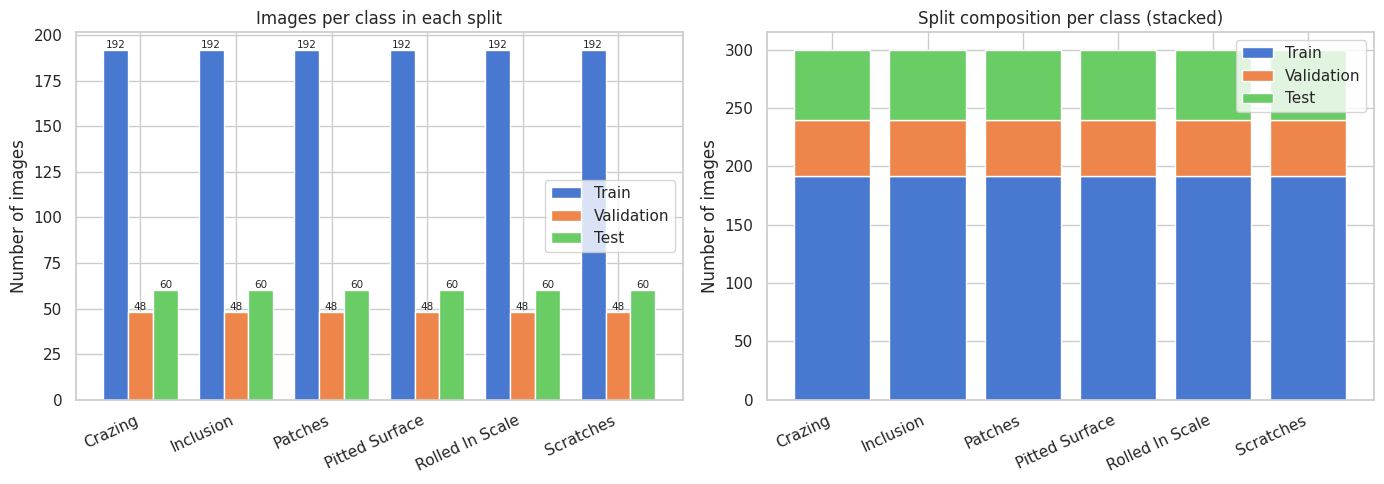

Saved plot -> artifacts/plots/02_split_proportions.png


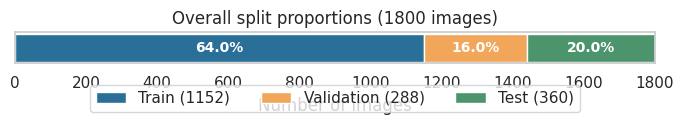

In [ ]:
# ------------------------------------------------------------------
# Split distribution chart
# ------------------------------------------------------------------

fig, (ax_grouped, ax_stacked) = plt.subplots(1, 2, figsize=(14, 5))

labels = [DISPLAY_NAMES[c] for c in CLASS_NAMES]
x_pos = np.arange(NUM_CLASSES)
width = 0.26

ax_grouped.bar(x_pos - width, split_stats["Train"], width, label="Train")
ax_grouped.bar(x_pos, split_stats["Validation"], width, label="Validation")
ax_grouped.bar(x_pos + width, split_stats["Test"], width, label="Test")

for i in range(NUM_CLASSES):
    for offset, column in zip((-width, 0, width),
                              ("Train", "Validation", "Test")):
        value = split_stats.loc[i, column]
        ax_grouped.text(i + offset, value, str(value), ha="center", va="bottom",
                        fontsize=7.5)

ax_grouped.set_xticks(x_pos)
ax_grouped.set_xticklabels(labels, rotation=25, ha="right")
ax_grouped.set_ylabel("Number of images")
ax_grouped.set_title("Images per class in each split")
ax_grouped.legend()

# Stacked view shows the per-class composition at a glance.
ax_stacked.bar(x_pos, split_stats["Train"], label="Train")
ax_stacked.bar(x_pos, split_stats["Validation"],
               bottom=split_stats["Train"], label="Validation")
ax_stacked.bar(x_pos, split_stats["Test"],
               bottom=split_stats["Train"] + split_stats["Validation"],
               label="Test")
ax_stacked.set_xticks(x_pos)
ax_stacked.set_xticklabels(labels, rotation=25, ha="right")
ax_stacked.set_ylabel("Number of images")
ax_stacked.set_title("Split composition per class (stacked)")
ax_stacked.legend()

plt.tight_layout()
save_fig(fig, "01_split_distribution.png")
plt.show()

# Overall split proportions.
fig2, ax = plt.subplots(figsize=(7, 1.9))
left = 0
for label, count, colour in [("Train", n_train, "#2a6f97"),
                             ("Validation", n_val, "#f2a65a"),
                             ("Test", n_test, "#4c956c")]:
    ax.barh(0, count, left=left, color=colour, label=f"{label} ({count})")
    ax.text(left + count / 2, 0, f"{count / n_total:.1%}", ha="center",
            va="center", color="white", fontweight="bold", fontsize=10)
    left += count
ax.set_yticks([])
ax.set_xlim(0, n_total)
ax.set_xlabel("Number of images")
ax.set_title(f"Overall split proportions ({n_total} images)")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.45))
ax.grid(False)
plt.tight_layout()
save_fig(fig2, "02_split_proportions.png")
plt.show()

---
## 4. Exploratory Image Analysis

Exploratory analysis for images answers the same three questions as Task 2a's EDA, in a
visual form:

1. **What does each class look like?** You cannot reason about a model's mistakes without
   knowing which classes genuinely resemble each other.
2. **Is the dataset balanced?** Class imbalance decides whether overall accuracy is a fair
   headline metric or a misleading one.
3. **Are the inputs consistent?** Mixed image sizes, colour modes or aspect ratios all
   change what preprocessing must do.

All exploration below uses the **training split only**. This mirrors Task 2a's rule about
not letting exploratory decisions leak from held-out data: looking closely at test images
before modelling is a subtle way of tuning to them.

### What the six defect categories represent

| Defect | Physical cause | Why it matters in production |
|---|---|---|
| **Crazing** | Thermal or mechanical stress producing a network of fine surface cracks | Cracks propagate under forming; a coil may need downgrading |
| **Inclusion** | Non-metallic material (slag, refractory) trapped and rolled into the strip | Weak points that can fail under load or spoil a coated finish |
| **Patches** | Uneven oxidation, pickling or coating producing discoloured regions | Mostly cosmetic, but rejected for visible-surface applications |
| **Pitted Surface** | Corrosion or over-pickling leaving small cavities | Reduces effective thickness and ruins surface finish |
| **Rolled-in Scale** | Oxide scale not removed by descaling, pressed into the metal by the rolls | Flakes off later, leaving voids; points at a descaling fault |
| **Scratches** | Mechanical contact with rolls, guides or handling equipment | Directional gouges; usually indicates a specific worn machine part |

Figures produced in this section are saved to `artifacts/plots/`.

Saved plot -> artifacts/plots/03_class_examples.png


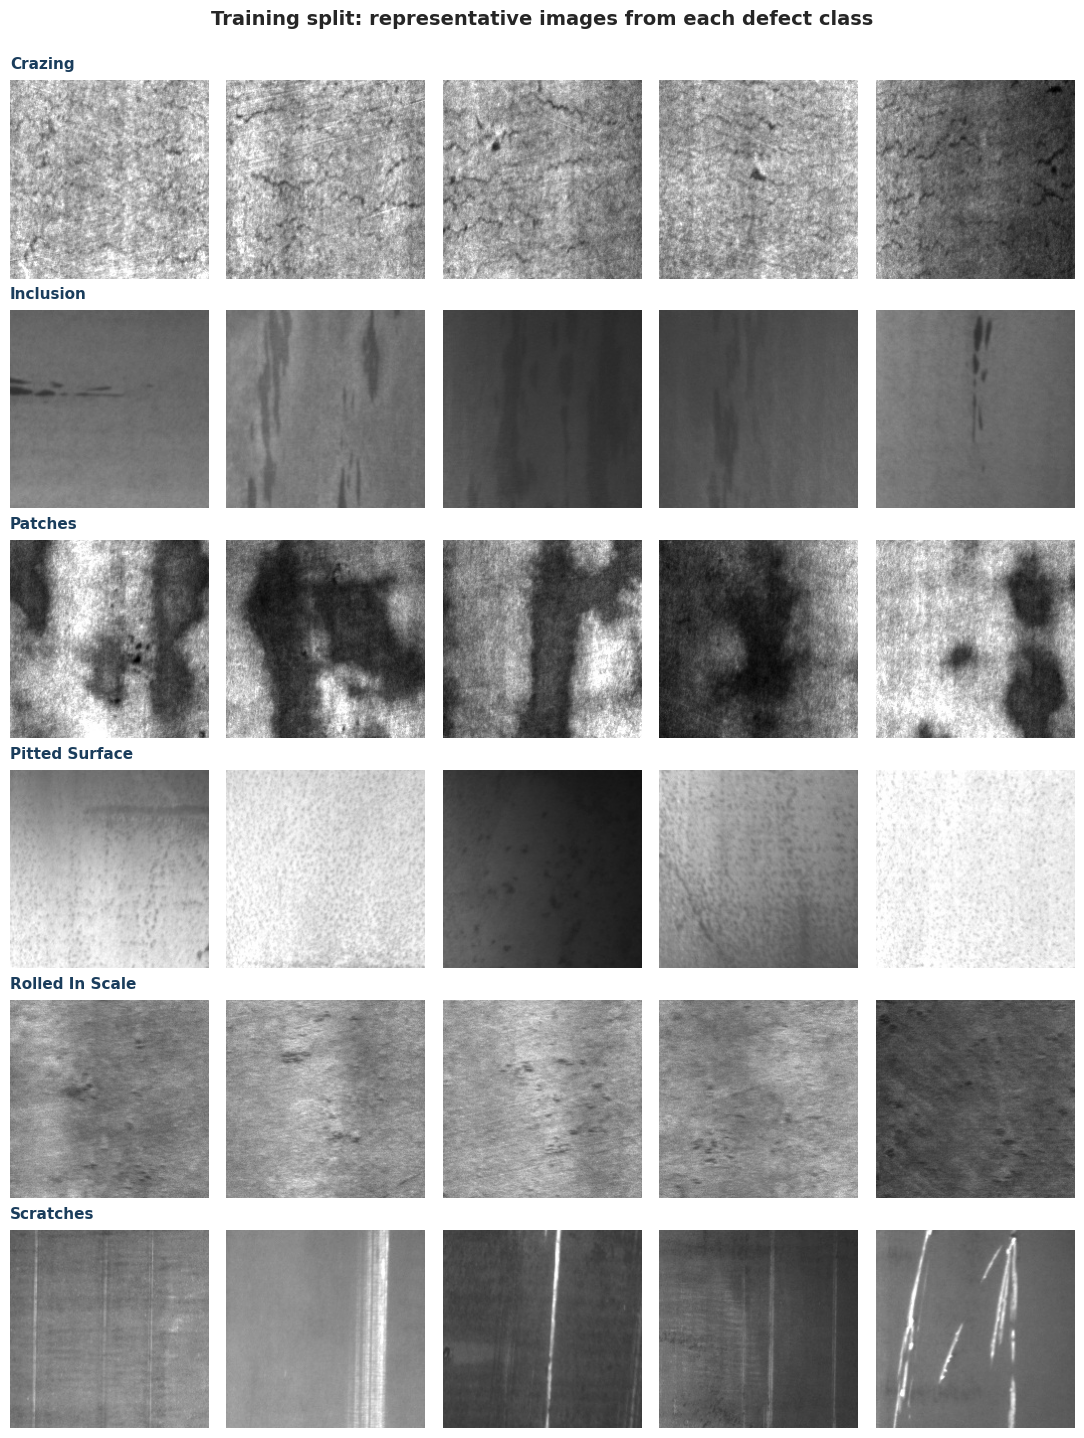

In [ ]:
# ------------------------------------------------------------------
# Representative images from all six defect classes (training split)
# ------------------------------------------------------------------

EXAMPLES_PER_CLASS = 5
rng = np.random.default_rng(RANDOM_STATE)

fig, axes = plt.subplots(
    NUM_CLASSES, EXAMPLES_PER_CLASS,
    figsize=(EXAMPLES_PER_CLASS * 2.2, NUM_CLASSES * 2.4),
)

for row, class_name in enumerate(CLASS_NAMES):
    files = train_catalogue[class_name]
    chosen = rng.choice(files, size=min(EXAMPLES_PER_CLASS, len(files)),
                        replace=False)

    for col in range(EXAMPLES_PER_CLASS):
        ax = axes[row, col]
        ax.axis("off")
        ax.grid(False)
        if col < len(chosen):
            with Image.open(chosen[col]) as img:
                ax.imshow(np.array(img), cmap="gray")
        if col == 0:
            ax.set_title(DISPLAY_NAMES[class_name], fontsize=11, loc="left",
                         pad=8, fontweight="bold", color="#1a3d5c")

fig.suptitle("Training split: representative images from each defect class",
             fontsize=14, fontweight="bold", y=0.998)
plt.tight_layout()
save_fig(fig, "03_class_examples.png")
plt.show()

Saved plot -> artifacts/plots/04_train_class_distribution.png


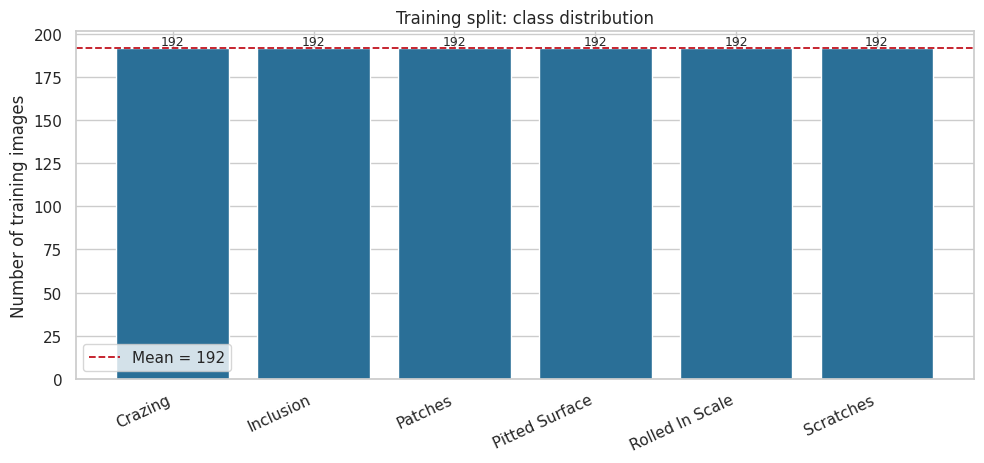

Imbalance ratio (largest / smallest class): 1.00
The training split is well balanced, so overall accuracy is a fair
headline metric. Per-class precision and recall are still reported.


In [ ]:
# ------------------------------------------------------------------
# Class balance within the training split
# ------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4.8))

train_counts_list = [len(train_catalogue[c]) for c in CLASS_NAMES]
x_pos = np.arange(NUM_CLASSES)

ax.bar(x_pos, train_counts_list, color="#2a6f97")
mean_count = float(np.mean(train_counts_list))
ax.axhline(mean_count, color="#c1121f", linestyle="--", linewidth=1.3,
           label=f"Mean = {mean_count:.0f}")
for i, value in enumerate(train_counts_list):
    ax.text(i, value, str(value), ha="center", va="bottom", fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels([DISPLAY_NAMES[c] for c in CLASS_NAMES], rotation=25, ha="right")
ax.set_ylabel("Number of training images")
ax.set_title("Training split: class distribution")
ax.legend()

plt.tight_layout()
save_fig(fig, "04_train_class_distribution.png")
plt.show()

imbalance_ratio = max(train_counts_list) / min(train_counts_list)
print(f"Imbalance ratio (largest / smallest class): {imbalance_ratio:.2f}")
if imbalance_ratio < 1.5:
    print("The training split is well balanced, so overall accuracy is a fair")
    print("headline metric. Per-class precision and recall are still reported.")
else:
    print("The training split is noticeably imbalanced - rely on the per-class")
    print("metrics rather than overall accuracy alone.")

---
## 5. Image Preprocessing and Data Augmentation

Task 2a cleaned a table: dropped identifiers, removed implausible values, imputed gaps.
The image equivalent is making every input the same shape and scale, then deliberately
adding variation so the model does not memorise.

### Preprocessing — applied to all three splits

| Step | Setting | Why |
|---|---|---|
| **Resize** | 224 × 224 | The size EfficientNetB0 was trained at; its filters are tuned to detail at that scale. NEU-DET images are near 200 × 200, so this is a mild upscale with little distortion. |
| **Grayscale → RGB** | 3 channels | The backbone expects three channels. The grey channel is replicated, which keeps the pretrained weights usable unchanged. |
| **Normalisation** | Architecture-specific | EfficientNet performs its own rescaling **inside** the network and expects raw 0–255 input. MobileNetV2 instead needs `[-1, 1]`. The correct behaviour for the selected backbone is built into the model in Section 7. |

Putting normalisation **inside the model** matters for deployment. The saved `.keras` file
then carries its own preprocessing, so Section 13's inference path and Section 15's Gradio
app cannot accidentally normalise differently from training — a classic and very
hard-to-diagnose source of silently wrong predictions. This is the image-data analogue of
Task 2a fitting its encoders inside a `Pipeline` rather than applying them by hand at
scoring time.

### Augmentation — applied to the training split only

There are only a few hundred training images per class, and the network has millions of
parameters. It has ample capacity to memorise every image — reaching near-perfect training
accuracy while failing on anything new. Augmentation shows the model a slightly different
version of each image every epoch, so it never sees the same input twice and is pushed
towards learning the *texture* of a defect rather than the specific pixels of one photograph.

The transformations are chosen to match variation a real inspection camera would encounter:

| Augmentation | Setting | Justification for steel surfaces |
|---|---|---|
| Horizontal + vertical flip | on | Surface texture has no inherent orientation — a scratch mirrored is the same defect, and the camera could view the strip from either side. |
| Small rotation | ±5% (≈ ±18°) | Strip is never perfectly aligned under the camera. Deliberately kept small: a 90° rotation would destroy the directional signal that separates *scratches* from *crazing*. |
| Zoom | ±10% | Camera distance and strip height vary on a real line. |
| Translation | ±10% | The defect is not always centred in the frame. |
| Contrast | ±15% | Lighting, oil film and oxidation change surface contrast between coils. |

Note what is **not** used: heavy colour jitter (the images are grayscale), large rotations,
and shear — none reflect real variation here, and each would make the task artificially
harder.

> **Validation and test images are never augmented.** They receive only the required
> preprocessing: resize and RGB conversion. The augmentation layers are active during
> `fit()` and pass images through untouched at evaluation and inference time — Keras handles
> that switch automatically, so there is no second code path to keep in sync.

In [ ]:
# ------------------------------------------------------------------
# Image and batch configuration
# ------------------------------------------------------------------

IMG_SIZE = (224, 224)     # EfficientNetB0 / MobileNetV2 native input size
IMG_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 32           # comfortable on a Colab T4; lower to 16 if you hit OOM

print(f"Input image size : {IMG_SIZE[0]} x {IMG_SIZE[1]} x 3")
print(f"Batch size       : {BATCH_SIZE}")

Input image size : 224 x 224 x 3
Batch size       : 32


In [ ]:
# ------------------------------------------------------------------
# Augmentation pipeline - TRAINING DATA ONLY
# ------------------------------------------------------------------
# These are Keras layers, so they live inside the model graph. They transform
# images during training and are inert during evaluation and inference, which
# is what keeps validation and test data augmentation-free.

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical", seed=RANDOM_STATE),
        layers.RandomRotation(0.05, fill_mode="reflect", seed=RANDOM_STATE),
        layers.RandomZoom(0.10, fill_mode="reflect", seed=RANDOM_STATE),
        layers.RandomTranslation(0.10, 0.10, fill_mode="reflect", seed=RANDOM_STATE),
        layers.RandomContrast(0.15, seed=RANDOM_STATE),
    ],
    name="data_augmentation",
)

print("Augmentation layers (training only):")
for layer in data_augmentation.layers:
    print(f"  - {layer.__class__.__name__}")

Augmentation layers (training only):
  - RandomFlip
  - RandomRotation
  - RandomZoom
  - RandomTranslation
  - RandomContrast


---
## 6. Build TensorFlow Dataset Pipelines

`image_dataset_from_directory` reads the class folders and produces a `tf.data.Dataset` of
`(images, labels)` batches. One pipeline per split, with settings that matter:

- **`label_mode="categorical"`** produces one-hot labels, which pairs with the
  `categorical_crossentropy` loss used in Section 8.
- **`shuffle=True` for training only.** Validation and test use `shuffle=False`.
  Deterministic ordering is not cosmetic: Sections 10 and 11 line predictions up against
  labels *by position*, and a shuffled set would silently misalign them and report nonsense.
- **`class_names=CLASS_NAMES`** pins the class-to-index mapping explicitly rather than
  relying on default directory ordering. That mapping is saved with the model in Section 12,
  so the index a prediction returns always resolves to the same defect name.

`prefetch(AUTOTUNE)` overlaps data loading with GPU compute. Validation and test are also
cached, since they are read unchanged on every pass.

In [ ]:
# ------------------------------------------------------------------
# One pipeline per split
# ------------------------------------------------------------------

def make_dataset(directory: Path, shuffle: bool):
    """Build a batched tf.data pipeline from a split directory."""
    return keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",          # the folder name is the label
        label_mode="categorical",
        class_names=CLASS_NAMES,    # pinned so the index order can never drift
        color_mode="rgb",           # grayscale replicated to 3 channels
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=RANDOM_STATE if shuffle else None,
    )


train_ds_raw = make_dataset(TRAIN_DIR, shuffle=True)
val_ds_raw = make_dataset(VALIDATION_DIR, shuffle=False)
test_ds_raw = make_dataset(TEST_DIR, shuffle=False)

for name, dataset in [("train", train_ds_raw), ("validation", val_ds_raw),
                      ("test", test_ds_raw)]:
    assert dataset.class_names == CLASS_NAMES, f"{name} class order mismatch"

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.prefetch(AUTOTUNE)
val_ds = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(AUTOTUNE)

# The class/index mapping - saved with the model in Section 12.
CLASS_INDEX_MAP = {name: idx for idx, name in enumerate(CLASS_NAMES)}

print("\n" + "=" * 66)
print("DATASET PIPELINES READY")
print("=" * 66)
print("Class name -> index mapping:")
for name, idx in CLASS_INDEX_MAP.items():
    print(f"  {idx}: {name:<18} ({DISPLAY_NAMES[name]})")
print("-" * 66)
print(f"Train batches      : {train_ds_raw.cardinality().numpy():3d}  "
      f"({n_train} images, shuffled, augmented)")
print(f"Validation batches : {val_ds_raw.cardinality().numpy():3d}  "
      f"({n_val} images, ordered, not augmented)")
print(f"Test batches       : {test_ds_raw.cardinality().numpy():3d}  "
      f"({n_test} images, ordered, not augmented, HELD OUT)")

for images, labels in train_ds.take(1):
    print(f"\nImage batch : {images.shape}  dtype={images.dtype}")
    print(f"Label batch : {labels.shape}  (one-hot)")
    print(f"Pixel range : {float(tf.reduce_min(images)):.1f} to "
          f"{float(tf.reduce_max(images)):.1f}  (raw 0-255)")
print("=" * 66)

Found 1152 files belonging to 6 classes.
Found 288 files belonging to 6 classes.
Found 360 files belonging to 6 classes.

DATASET PIPELINES READY
Class name -> index mapping:
  0: crazing            (Crazing)
  1: inclusion          (Inclusion)
  2: patches            (Patches)
  3: pitted_surface     (Pitted Surface)
  4: rolled-in_scale    (Rolled In Scale)
  5: scratches          (Scratches)
------------------------------------------------------------------
Train batches      :  36  (1152 images, shuffled, augmented)
Validation batches :   9  (288 images, ordered, not augmented)
Test batches       :  12  (360 images, ordered, not augmented, HELD OUT)

Image batch : (32, 224, 224, 3)  dtype=<dtype: 'float32'>
Label batch : (32, 6)  (one-hot)
Pixel range : 0.0 to 255.0  (raw 0-255)


Saved plot -> artifacts/plots/05_augmentation_examples.png


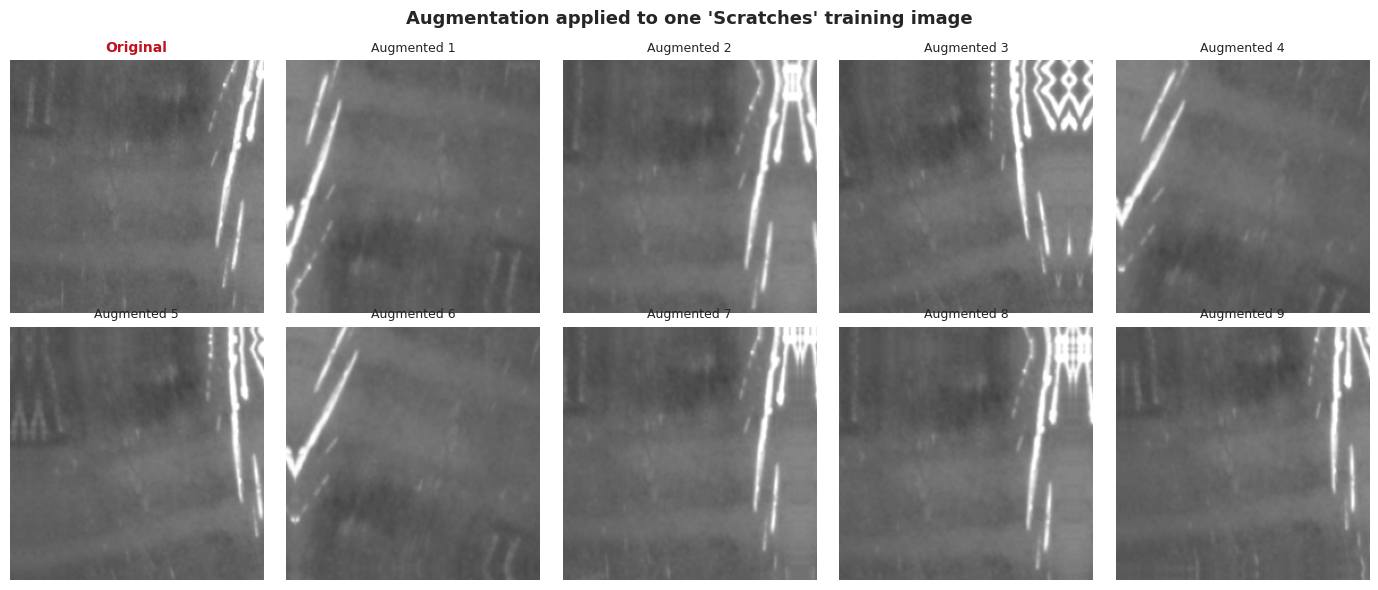

In [ ]:
# ------------------------------------------------------------------
# Visual check: augmentation applied to a single training image
# ------------------------------------------------------------------
# Worth eyeballing - augmentation that is too aggressive destroys the very
# signal the model needs, and that failure is invisible in the loss curve.

for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_class = CLASS_NAMES[int(tf.argmax(labels[0]))]
    break

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

axes[0].imshow(sample_image.numpy().astype("uint8"))
axes[0].set_title("Original", fontsize=10, fontweight="bold", color="#c1121f")
axes[0].axis("off")

for i in range(1, 10):
    augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    axes[i].imshow(tf.clip_by_value(augmented[0], 0, 255).numpy().astype("uint8"))
    axes[i].set_title(f"Augmented {i}", fontsize=9)
    axes[i].axis("off")

for ax in axes:
    ax.grid(False)

fig.suptitle(f"Augmentation applied to one '{DISPLAY_NAMES[sample_class]}' "
             "training image", fontsize=13, fontweight="bold")
plt.tight_layout()
save_fig(fig, "05_augmentation_examples.png")
plt.show()

---
## 7. Transfer-Learning Model

### Theory

A **convolutional neural network (CNN)** learns spatial feature detectors rather than
consuming hand-specified columns. Each convolutional layer slides small learnable filters
across the image; early layers respond to edges and simple textures, and deeper layers
combine those responses into progressively more abstract patterns. Crucially the model
*learns* which features matter — there is no feature-engineering step equivalent to Task
2a's one-hot encoding.

**Why not train a CNN from scratch here?** Because NEU-DET is small. A network with millions
of parameters and only a few hundred images per class will memorise the training set almost
immediately.

**Transfer learning** solves this. **EfficientNetB0** pretrained on **ImageNet** (1.2 million
images, 1000 categories) has already learned a general visual vocabulary: edges, corners,
repeating texture, directional gradients, blob-like regions. Those features are not specific
to cats and cars — they are the raw material of any visual recognition task, and they are
precisely what distinguishes a directional scratch from a network of crazing cracks.

The strategy has two stages:

| Stage | Backbone | Learning rate | What is learned |
|---|---|---|---|
| **Feature extraction** (Section 8) | **Frozen** | `1e-3` | Only the new classification head |
| **Fine-tuning** (Section 9) | **Upper layers unfrozen** | `1e-5` | Head + the most specialised backbone features |

In feature-extraction mode the backbone is a fixed function turning each image into a
compact feature vector, and only a few thousand parameters are trained — an amount a small
dataset can comfortably support.

### Architecture

```
Input image (224 × 224 × 3)
      ↓
Data augmentation          ← training only, inert on validation and test
      ↓
[Rescaling]                ← only for MobileNetV2; EfficientNet normalises internally
      ↓
EfficientNetB0             ← ImageNet weights, FROZEN in Section 8
      ↓
GlobalAveragePooling2D     ← feature maps → one feature vector
      ↓
Dropout (0.3)              ← regularisation
      ↓
Dense (6, softmax)         ← six defect probabilities
```

**`GlobalAveragePooling2D` rather than `Flatten`** is deliberate. Flatten would produce a
very wide vector and a head with millions of parameters — exactly the overfitting risk
transfer learning is meant to avoid. Global average pooling collapses each feature map to a
single number, giving a compact and translation-tolerant representation. That tolerance is
useful here: a scratch is a scratch wherever it sits in the frame.

**`Dropout(0.3)`** randomly zeroes 30% of features during training, preventing the head from
leaning too heavily on any single feature — the same variance-reduction motive as bagging in
Task 2a's Random Forest, applied to a neural network.

In [ ]:
# ------------------------------------------------------------------
# Load the pretrained backbone
# ------------------------------------------------------------------
# EfficientNetB0 is the preferred architecture; MobileNetV2 is a supported
# fallback. The correct normalisation for each is handled below.

BACKBONE = "EfficientNetB0"      # <-- "EfficientNetB0" or "MobileNetV2"

if BACKBONE == "EfficientNetB0":
    base_model = keras.applications.EfficientNetB0(
        input_shape=IMG_SHAPE,
        include_top=False,       # drop the 1000-class ImageNet classifier
        weights="imagenet",
    )
    # EfficientNet normalises internally and expects raw 0-255 input, so this
    # layer is a deliberate no-op kept for architectural symmetry.
    preprocessing_layer = layers.Rescaling(1.0, name="preprocessing")
    FINE_TUNE_AT = 200           # layer index to unfreeze from in Section 9

elif BACKBONE == "MobileNetV2":
    base_model = keras.applications.MobileNetV2(
        input_shape=IMG_SHAPE,
        include_top=False,
        weights="imagenet",
    )
    # MobileNetV2 expects [-1, 1]. Expressing that as a Rescaling layer, rather
    # than a Lambda wrapping preprocess_input, keeps the saved .keras file
    # self-contained and safe to reload anywhere.
    preprocessing_layer = layers.Rescaling(1.0 / 127.5, offset=-1.0,
                                           name="preprocessing")
    FINE_TUNE_AT = 100

else:
    raise ValueError(
        f"Unsupported BACKBONE '{BACKBONE}'. Use 'EfficientNetB0' or 'MobileNetV2'."
    )

# Feature-extraction stage: the pretrained weights do not move.
base_model.trainable = False

print(f"Backbone          : {BACKBONE}")
print(f"Backbone layers   : {len(base_model.layers)}")
print(f"Backbone params   : {base_model.count_params():,} (frozen)")
print(f"Output feature map: {base_model.output_shape}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Backbone          : EfficientNetB0
Backbone layers   : 238
Backbone params   : 4,049,571 (frozen)
Output feature map: (None, 7, 7, 1280)


In [ ]:
# ------------------------------------------------------------------
# Assemble the classification model
# ------------------------------------------------------------------

inputs = keras.Input(shape=IMG_SHAPE, name="steel_surface_image")

x = data_augmentation(inputs)        # active during training only
x = preprocessing_layer(x)           # normalisation travels with the model

# training=False keeps the backbone's BatchNormalization layers in inference
# mode. This is essential with a frozen backbone: otherwise BN would keep
# updating its running statistics from steel images while the weights stay
# fixed, quietly corrupting the pretrained features.
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dropout(0.3, name="head_dropout")(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax",
                       name="defect_class")(x)

model = keras.Model(inputs, outputs, name="steel_defect_classifier")

model.summary()

trainable_params = int(sum(np.prod(w.shape) for w in model.trainable_weights))
frozen_params = int(sum(np.prod(w.shape) for w in model.non_trainable_weights))

print("\n" + "=" * 66)
print(f"Trainable parameters     : {trainable_params:,}")
print(f"Non-trainable (frozen)   : {frozen_params:,}")
print(f"Total parameters         : {trainable_params + frozen_params:,}")
print("=" * 66)
print("Only the classification head trains in Stage 1 - a small parameter count,")
print("which is exactly what a dataset this size can support.")

Model: "steel_defect_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ steel_surface_image             │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing (Rescaling)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ defect_class (Dense)            │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Trainable parameters     : 7,686
Non-trainable (frozen)   : 4,049,571
Total parameters         : 4,057,257
Only the classification head trains in Stage 1 - a small parameter count,
which is exactly what a dataset this size can support.


---
## 8. Initial Training

### Training configuration

**Loss — categorical cross-entropy.** Six mutually exclusive classes, one-hot labels and a
softmax output. Cross-entropy penalises confident wrong answers far more harshly than
hesitant ones, which is the behaviour you want from an inspection system.

**Optimiser — Adam at `1e-3`.** Adam adapts the step size per parameter and needs little
manual tuning. `1e-3` is comparatively brisk, which is appropriate here because only the
randomly-initialised head is training — the pretrained weights are frozen and in no danger
of being disturbed.

### Callbacks — all driven by the validation split

| Callback | Setting | Role |
|---|---|---|
| `EarlyStopping` | `monitor="val_accuracy"`, `patience=5`, `restore_best_weights=True` | Stops when validation accuracy has not improved for 5 epochs and rolls the weights back to the best epoch. This is what makes a generous epoch budget safe — the final weights are the best seen, not the last. |
| `ReduceLROnPlateau` | `factor=0.3`, `patience=3` | When validation loss stalls, cuts the learning rate to 30%. Often the model is circling a minimum with too large a step; a smaller step lets it settle. |
| `ModelCheckpoint` | `save_best_only=True` | Writes the best model to `artifacts/model/` whenever validation accuracy improves — insurance against a Colab disconnection mid-run. |

Every callback monitors the **validation** split. The training split cannot be used for this
— a model can drive training accuracy up indefinitely by memorising. The **test split is not
touched here at all**, which is what keeps Section 11's result unbiased.

> This cell performs real training and will take several minutes. Nothing below is
> pre-computed — all metrics come from this run.

In [ ]:
# ------------------------------------------------------------------
# Stage 1: train the classification head (backbone frozen)
# ------------------------------------------------------------------

INITIAL_EPOCHS = 20        # upper bound; early stopping usually ends sooner
INITIAL_LR = 1e-3

STAGE1_MODEL_PATH = MODEL_DIR / "checkpoint_stage1.keras"

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_stage1 = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=str(STAGE1_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0,
    ),
]

print("=" * 66)
print("STAGE 1 - FEATURE EXTRACTION (backbone frozen)")
print("=" * 66)
print(f"Training on   : {n_train} images (augmented)")
print(f"Validating on : {n_val} images")
print(f"Test set      : {n_test} images - NOT touched in this section")
print(f"Max epochs    : {INITIAL_EPOCHS}")
print(f"Learning rate : {INITIAL_LR}")
print("=" * 66 + "\n")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks_stage1,
    verbose=1,
)

# Guarantee the stage-1 model exists on disk even if the checkpoint never fired.
if not STAGE1_MODEL_PATH.exists():
    model.save(STAGE1_MODEL_PATH)

print("\n" + "=" * 66)
print("STAGE 1 COMPLETE")
print("=" * 66)
print(f"Epochs run        : {len(history.history['loss'])}")
print(f"Best val accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best val loss     : {min(history.history['val_loss']):.4f}")
print(f"Saved             : {STAGE1_MODEL_PATH.relative_to(PROJECT_ROOT)}")
print("=" * 66)

STAGE 1 - FEATURE EXTRACTION (backbone frozen)
Training on   : 1152 images (augmented)
Validating on : 288 images
Test set      : 360 images - NOT touched in this section
Max epochs    : 20
Learning rate : 0.001

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 244ms/step - accuracy: 0.6345 - loss: 1.2072 - val_accuracy: 0.8194 - val_loss: 0.8690 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step - accuracy: 0.9115 - loss: 0.5694 - val_accuracy: 0.8889 - val_loss: 0.5422 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 139ms/step - accuracy: 0.9470 - loss: 0.3739 - val_accuracy: 0.9271 - val_loss: 0.3804 - learning_rate: 0.0010
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.9557 - loss: 0.2741 - val_accuracy: 0.9410 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9653 - loss: 0.2197 - val_accuracy: 0.9410 - val_loss: 0.2722 - learning_rate: 0.0010
Epoch 6/20
36/36 ━━━━━━━━━━

---
## 9. Fine-Tuning

The head is trained; the backbone has not moved. Fine-tuning now unfreezes the **upper**
layers of the backbone and continues training at a much smaller learning rate.

### Feature extraction vs fine-tuning

| | Feature extraction (Section 8) | Fine-tuning (this section) |
|---|---|---|
| Backbone weights | Entirely frozen | Upper layers trainable |
| Learning rate | `1e-3` | `1e-5` (100× smaller) |
| Trainable parameters | Head only (~thousands) | Head + upper backbone (~millions) |
| Risk | Underfitting — ImageNet features may not be specific enough | Catastrophic forgetting if the learning rate is too high |
| Typical gain | Establishes a solid baseline quickly | A further few points of accuracy |

### Why only the upper layers

A CNN learns in a hierarchy. Early layers detect edges, colours and simple textures —
universal features that steel needs just as much as ImageNet did, and which there is nothing
to gain from disturbing. Later layers assemble those primitives into increasingly
object-specific concepts, and ImageNet's notion of "object-specific" means dog faces and car
wheels. Those are the layers worth re-specialising towards scale, pitting and crazing.

### Why the learning rate drops 100×

At `1e-3`, the large gradients flowing from a freshly-trained head would tear through
carefully pretrained weights and destroy the very features that made transfer learning work
— the failure mode known as **catastrophic forgetting**. `1e-5` nudges them instead.

### Why BatchNorm layers stay frozen

BatchNormalization layers hold running mean and variance statistics inherited from ImageNet.
With batches of only 32 images, letting those statistics update produces noisy estimates
that destabilise training. Keeping BN in inference mode is standard practice when
fine-tuning on a small dataset.

Fine-tuning is **not automatically an improvement**. Section 10 compares this model against
the Stage 1 model on the validation split and keeps whichever is better — that comparison is
a model-selection decision, which is exactly what a validation set is for.

> Set `RUN_FINE_TUNING = False` to skip this stage. Section 10 then simply selects the
> Stage 1 model.

In [ ]:
# ------------------------------------------------------------------
# Stage 2: fine-tune the upper backbone
# ------------------------------------------------------------------

RUN_FINE_TUNING = True     # set to False to skip this stage

FINE_TUNE_EPOCHS = 10      # additional epochs on top of Stage 1
FINE_TUNE_LR = 1e-5        # 100x smaller than Stage 1

FINETUNED_MODEL_PATH = MODEL_DIR / "checkpoint_finetuned.keras"

history_fine = None

if RUN_FINE_TUNING:
    base_model.trainable = True

    # Freeze everything below the cut-off, and keep ALL BatchNorm layers frozen.
    n_frozen = n_unfrozen = 0
    for idx, layer in enumerate(base_model.layers):
        if idx < FINE_TUNE_AT or isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
            n_frozen += 1
        else:
            layer.trainable = True
            n_unfrozen += 1

    # Recompiling is mandatory - without it Keras keeps the old frozen graph.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    params_now = int(sum(np.prod(w.shape) for w in model.trainable_weights))

    print("=" * 66)
    print("STAGE 2 - FINE-TUNING")
    print("=" * 66)
    print(f"Unfreezing from layer  : {FINE_TUNE_AT} of {len(base_model.layers)}")
    print(f"Backbone layers frozen : {n_frozen}")
    print(f"Backbone layers open   : {n_unfrozen}")
    print(f"Trainable parameters   : {params_now:,}")
    print(f"Learning rate          : {FINE_TUNE_LR}")
    print(f"Test set               : still untouched")
    print("=" * 66 + "\n")

    callbacks_stage2 = [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=5,
            restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3, patience=3,
            min_lr=1e-8, verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(FINETUNED_MODEL_PATH),
            monitor="val_accuracy", save_best_only=True, verbose=0,
        ),
    ]

    # initial_epoch continues the epoch numbering so Section 10's curves join up.
    epochs_so_far = len(history.history["loss"])

    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs_so_far + FINE_TUNE_EPOCHS,
        initial_epoch=epochs_so_far,
        callbacks=callbacks_stage2,
        verbose=1,
    )

    if not FINETUNED_MODEL_PATH.exists():
        model.save(FINETUNED_MODEL_PATH)

    print("\n" + "=" * 66)
    print("STAGE 2 COMPLETE")
    print("=" * 66)
    print(f"Best val accuracy - stage 1 : {max(history.history['val_accuracy']):.4f}")
    print(f"Best val accuracy - stage 2 : {max(history_fine.history['val_accuracy']):.4f}")
    print(f"Saved                       : "
          f"{FINETUNED_MODEL_PATH.relative_to(PROJECT_ROOT)}")
    print("=" * 66)
else:
    print("Fine-tuning skipped (RUN_FINE_TUNING = False).")
    print("Section 10 will select the Stage 1 feature-extraction model.")

STAGE 2 - FINE-TUNING
Unfreezing from layer  : 200 of 238
Backbone layers frozen : 208
Backbone layers open   : 30
Trainable parameters   : 2,045,206
Learning rate          : 1e-05
Test set               : still untouched

Epoch 21/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accuracy: 0.9844 - loss: 0.0631 - val_accuracy: 0.9826 - val_loss: 0.0884 - learning_rate: 1.0000e-05
Epoch 22/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.9887 - loss: 0.0513 - val_accuracy: 0.9861 - val_loss: 0.0594 - learning_rate: 1.0000e-05
Epoch 23/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.9931 - loss: 0.0416 - val_accuracy: 0.9826 - val_loss: 0.0625 - learning_rate: 1.0000e-05
Epoch 24/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.9887 - loss: 0.0380 - val_accuracy: 0.9896 - val_loss: 0.0549 - learning_rate: 1.0000e-05
Epoch 25/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.9931 - loss: 0.0250 - val_accuracy: 0.9896 - val_loss: 0.0457 - learning_rate: 1.

---
## 10. Validation-Based Model Selection

Training has produced **two candidate models**:

1. The Stage 1 feature-extraction model (`checkpoint_stage1.keras`)
2. The Stage 2 fine-tuned model (`checkpoint_finetuned.keras`)

Fine-tuning usually helps, but not always — on a small dataset it can overfit. Which model
to ship is a **development decision**, and development decisions are made on the
**validation** split.

This mirrors Task 2a exactly. There, Random Forest and XGBoost were compared on validation
to choose a winner, and only then was the winner evaluated on test. The reasoning is
identical: *using the test set to choose between candidates would optimistically bias the
reported performance*, because you would be selecting whichever model happened to suit the
test data.

So this section:

1. Loads both candidates from disk
2. Scores each on the **validation** split
3. Selects the better one
4. Plots the training curves

The test set is still untouched. It is opened for the first and only time in Section 11.

Saved plot -> artifacts/plots/06_training_curves.png


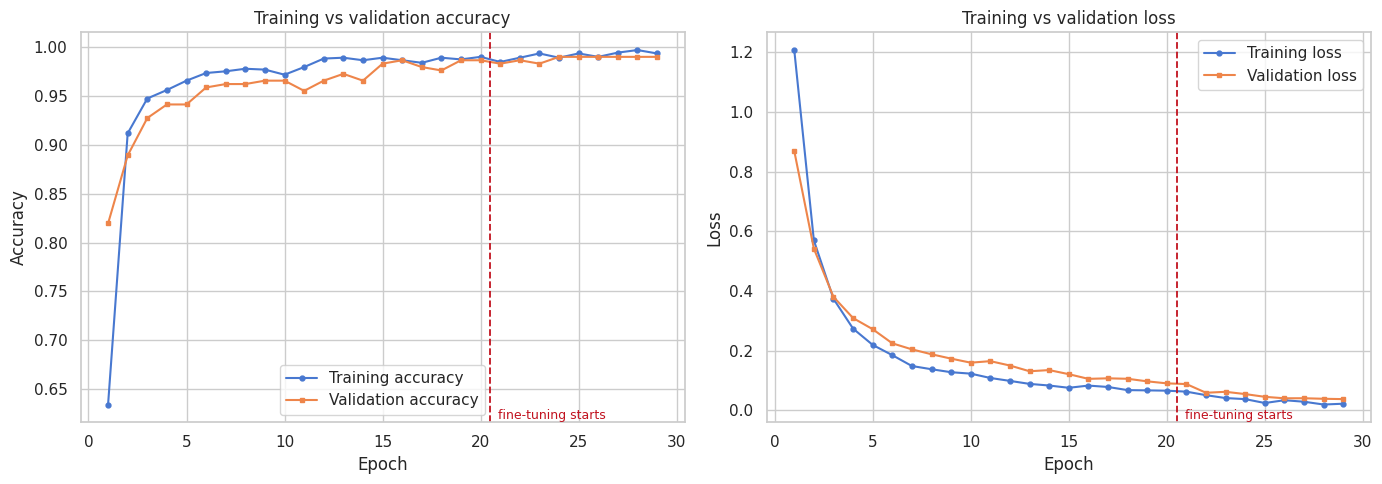

Final training accuracy   : 0.9931
Final validation accuracy : 0.9896
Gap (train - validation)  : +0.0035

The curves stay close, so the model is generalising rather than
memorising the training images.


In [ ]:
# ------------------------------------------------------------------
# Training curves across both stages
# ------------------------------------------------------------------

def merge_histories(first, second=None) -> dict:
    """Concatenate two Keras History objects into one dict of lists."""
    merged = {key: list(values) for key, values in first.history.items()}
    if second is not None:
        for key, values in second.history.items():
            merged.setdefault(key, []).extend(values)
    return merged


full_history = merge_histories(history, history_fine)
epochs_axis = range(1, len(full_history["accuracy"]) + 1)
stage1_epochs = len(history.history["accuracy"])

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))

ax_acc.plot(epochs_axis, full_history["accuracy"], "o-", ms=3.5,
            label="Training accuracy")
ax_acc.plot(epochs_axis, full_history["val_accuracy"], "s-", ms=3.5,
            label="Validation accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.set_title("Training vs validation accuracy")
ax_acc.legend()

ax_loss.plot(epochs_axis, full_history["loss"], "o-", ms=3.5,
             label="Training loss")
ax_loss.plot(epochs_axis, full_history["val_loss"], "s-", ms=3.5,
             label="Validation loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.set_title("Training vs validation loss")
ax_loss.legend()

if history_fine is not None:
    for ax in (ax_acc, ax_loss):
        ax.axvline(stage1_epochs + 0.5, color="#c1121f", linestyle="--", lw=1.3)
        ax.text(stage1_epochs + 0.7, ax.get_ylim()[0], " fine-tuning starts",
                color="#c1121f", fontsize=9, va="bottom")

plt.tight_layout()
save_fig(fig, "06_training_curves.png")
plt.show()

train_val_gap = full_history["accuracy"][-1] - full_history["val_accuracy"][-1]
print(f"Final training accuracy   : {full_history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy : {full_history['val_accuracy'][-1]:.4f}")
print(f"Gap (train - validation)  : {train_val_gap:+.4f}")
if train_val_gap > 0.10:
    print("\nA gap this wide suggests overfitting: the model fits training images")
    print("better than it generalises. More augmentation, higher dropout or fewer")
    print("unfrozen layers would be the levers to try.")
else:
    print("\nThe curves stay close, so the model is generalising rather than")
    print("memorising the training images.")

In [ ]:
# ------------------------------------------------------------------
# Compare the candidates on the VALIDATION split and select a winner
# ------------------------------------------------------------------
# This is a development decision, so it uses validation data only.

candidates = {"Stage 1 (feature extraction)": STAGE1_MODEL_PATH}
if RUN_FINE_TUNING and FINETUNED_MODEL_PATH.exists():
    candidates["Stage 2 (fine-tuned)"] = FINETUNED_MODEL_PATH

candidate_rows = []
loaded_candidates = {}

for label, path in candidates.items():
    candidate = keras.models.load_model(path)
    loaded_candidates[label] = candidate

    loss_value, accuracy_value = candidate.evaluate(val_ds, verbose=0)
    probabilities = candidate.predict(val_ds, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    truths = np.argmax(
        np.concatenate([labels for _, labels in val_ds], axis=0), axis=1)

    precision_v, recall_v, f1_v, _ = precision_recall_fscore_support(
        truths, predictions, average="macro", zero_division=0)

    candidate_rows.append({
        "model": label,
        "val_accuracy": round(float(accuracy_value), 4),
        "val_loss": round(float(loss_value), 4),
        "val_precision_macro": round(float(precision_v), 4),
        "val_recall_macro": round(float(recall_v), 4),
        "val_f1_macro": round(float(f1_v), 4),
        "path": str(path.relative_to(PROJECT_ROOT)),
    })

comparison_val = pd.DataFrame(candidate_rows).set_index("model")
print("Candidate comparison on the VALIDATION split:")
display(comparison_val.drop(columns=["path"]))

# Select on validation accuracy, with macro F1 as the tie-breaker.
comparison_val["_rank_key"] = list(zip(comparison_val["val_accuracy"],
                                       comparison_val["val_f1_macro"]))
SELECTED_MODEL_NAME = comparison_val["_rank_key"].idxmax()
SELECTED_MODEL_PATH = Path(PROJECT_ROOT) / comparison_val.loc[
    SELECTED_MODEL_NAME, "path"]
selected_model = loaded_candidates[SELECTED_MODEL_NAME]
comparison_val = comparison_val.drop(columns=["_rank_key"])

print("\n" + "=" * 66)
print("MODEL SELECTED (on validation data)")
print("=" * 66)
print(f"Winner            : {SELECTED_MODEL_NAME}")
print(f"Validation accuracy: "
      f"{comparison_val.loc[SELECTED_MODEL_NAME, 'val_accuracy']:.4f}")
print(f"Artifact          : {SELECTED_MODEL_PATH.relative_to(PROJECT_ROOT)}")
print("=" * 66)

if len(candidates) > 1:
    stage1_acc = comparison_val.loc["Stage 1 (feature extraction)", "val_accuracy"]
    stage2_acc = comparison_val.loc["Stage 2 (fine-tuned)", "val_accuracy"]
    delta = stage2_acc - stage1_acc
    verdict = "improved" if delta > 0 else ("made no difference to" if delta == 0
                                            else "hurt")
    print(f"\nFine-tuning {verdict} validation accuracy by {delta:+.4f}.")
    print("That judgement was made on validation data - the test set has still")
    print("not been used.")

# Persist the comparison as an artifact.
VAL_COMPARISON_PATH = METRICS_DIR / "validation_model_comparison.json"
VAL_COMPARISON_PATH.write_text(json.dumps({
    "candidates": candidate_rows,
    "selected_model": SELECTED_MODEL_NAME,
    "selection_metric": "validation accuracy (macro F1 tie-breaker)",
    "evaluated_at_utc": datetime.now(timezone.utc).isoformat(),
}, indent=2))
print(f"\nSaved -> {VAL_COMPARISON_PATH.relative_to(PROJECT_ROOT)}")

Candidate comparison on the VALIDATION split:


,val_accuracy,val_loss,val_precision_macro,val_recall_macro,val_f1_macro
model,,,,,
Stage 1 (feature extraction),0.9861,0.1059,0.9867,0.9861,0.9861
Stage 2 (fine-tuned),0.9896,0.0549,0.9899,0.9896,0.9896



MODEL SELECTED (on validation data)
Winner            : Stage 2 (fine-tuned)
Validation accuracy: 0.9896
Artifact          : artifacts/model/checkpoint_finetuned.keras

Fine-tuning improved validation accuracy by +0.0035.
That judgement was made on validation data - the test set has still
not been used.

Saved -> artifacts/metrics/validation_model_comparison.json


---
## 11. Final Test Evaluation

All training and model-selection decisions are now complete. The selected model is evaluated
**once** on the test split — images that come from `NEU-DET/validation/images`, were copied
into `data/test/` in Section 3, and have not influenced a single decision since.

**The numbers in this section are the ones to report.** They are an unbiased estimate of how
the model performs on steel surfaces it has never encountered, because nothing about the
model was chosen by looking at them.

The metrics reported:

- **Accuracy** — overall proportion correct.
- **Precision** (per class) — when the model says *scratches*, how often is it right? Low
  precision means false alarms, and false alarms mean scrapping good steel.
- **Recall** (per class) — of all the real *scratches*, how many were caught? Low recall
  means defects escaping to the customer, which is the expensive failure.
- **Macro F1** — the harmonic mean of precision and recall, averaged equally across classes.
- **Confusion matrix** — which classes get mistaken for which. Far more actionable than a
  single score, because it says *where* the model is weak rather than only *that* it is.

**Macro vs weighted averages** are both reported. Macro treats every class equally; weighted
accounts for class size. On a balanced dataset they land close together, and a large gap
between them is itself a signal worth noticing.

> A gap between validation and test performance is normal and expected. Validation accuracy
> is slightly optimistic precisely *because* it drove early stopping and model selection —
> which is the entire reason a separate test set exists.

In [ ]:
# ------------------------------------------------------------------
# Evaluate the selected model ONCE on the held-out test split
# ------------------------------------------------------------------
# test_ds was built with shuffle=False, so predictions and labels align by
# position. This is the step that would break silently if it were shuffled.

print(f"Evaluating '{SELECTED_MODEL_NAME}' on {n_test} held-out test images...\n")

test_loss, test_accuracy_keras = selected_model.evaluate(test_ds, verbose=0)

y_prob = selected_model.predict(test_ds, verbose=0)    # (n_test, 6)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(np.concatenate([labels for _, labels in test_ds], axis=0),
                   axis=1)
y_confidence = np.max(y_prob, axis=1)

assert len(y_true) == len(y_pred) == n_test, "prediction/label length mismatch"

test_accuracy = accuracy_score(y_true, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0)

print("=" * 66)
print("FINAL TEST PERFORMANCE  (reported result)")
print("=" * 66)
print(f"Model evaluated     : {SELECTED_MODEL_NAME}")
print(f"Test images         : {len(y_true)}")
print(f"Correct predictions : {int((y_true == y_pred).sum())}")
print(f"Test loss           : {test_loss:.4f}")
print("-" * 66)
print(f"Test accuracy       : {test_accuracy:.4f}  ({test_accuracy:.2%})")
print("-" * 66)
print(f"Precision (macro)   : {precision_macro:.4f}")
print(f"Recall    (macro)   : {recall_macro:.4f}")
print(f"F1-score  (macro)   : {f1_macro:.4f}")
print("-" * 66)
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall    (weighted): {recall_weighted:.4f}")
print(f"F1-score  (weighted): {f1_weighted:.4f}")
print("=" * 66)

selected_val_accuracy = float(
    comparison_val.loc[SELECTED_MODEL_NAME, "val_accuracy"])
print(f"\nValidation accuracy (used for selection) : {selected_val_accuracy:.4f}")
print(f"Test accuracy (unbiased estimate)        : {test_accuracy:.4f}")
print(f"Difference                               : "
      f"{test_accuracy - selected_val_accuracy:+.4f}")

print(f"\nMean confidence on correct predictions   : "
      f"{y_confidence[y_true == y_pred].mean():.4f}")
if (y_true != y_pred).any():
    print(f"Mean confidence on incorrect predictions : "
          f"{y_confidence[y_true != y_pred].mean():.4f}")
    print("\nIdeally wrong predictions carry lower confidence - that is what makes")
    print("a confidence threshold useful for routing uncertain images to a human.")
else:
    print("No incorrect predictions on this test set.")

Evaluating 'Stage 2 (fine-tuned)' on 360 held-out test images...

FINAL TEST PERFORMANCE  (reported result)
Model evaluated     : Stage 2 (fine-tuned)
Test images         : 360
Correct predictions : 335
Test loss           : 0.1646
------------------------------------------------------------------
Test accuracy       : 0.9306  (93.06%)
------------------------------------------------------------------
Precision (macro)   : 0.9380
Recall    (macro)   : 0.9306
F1-score  (macro)   : 0.9301
------------------------------------------------------------------
Precision (weighted): 0.9380
Recall    (weighted): 0.9306
F1-score  (weighted): 0.9301

Validation accuracy (used for selection) : 0.9896
Test accuracy (unbiased estimate)        : 0.9306
Difference                               : -0.0590

Mean confidence on correct predictions   : 0.9499
Mean confidence on incorrect predictions : 0.6542

Ideally wrong predictions carry lower confidence - that is what makes
a confidence threshold useful 

In [ ]:
# ------------------------------------------------------------------
# Test-set classification report
# ------------------------------------------------------------------

pretty_labels = [DISPLAY_NAMES[c] for c in CLASS_NAMES]

print("=" * 72)
print("TEST-SET CLASSIFICATION REPORT")
print("=" * 72)
print(classification_report(y_true, y_pred, target_names=pretty_labels,
                            digits=4, zero_division=0))

report_dict = classification_report(y_true, y_pred, target_names=pretty_labels,
                                    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose().round(4)
display(report_df)

TEST-SET CLASSIFICATION REPORT
                 precision    recall  f1-score   support

        Crazing     0.9524    1.0000    0.9756        60
      Inclusion     0.9344    0.9500    0.9421        60
        Patches     1.0000    1.0000    1.0000        60
 Pitted Surface     1.0000    0.8333    0.9091        60
Rolled In Scale     0.8000    1.0000    0.8889        60
      Scratches     0.9412    0.8000    0.8649        60

       accuracy                         0.9306       360
      macro avg     0.9380    0.9306    0.9301       360
   weighted avg     0.9380    0.9306    0.9301       360



,precision,recall,f1-score,support
Crazing,0.9524,1.0000,0.9756,60.0000
Inclusion,0.9344,0.9500,0.9421,60.0000
Patches,1.0000,1.0000,1.0000,60.0000
Pitted Surface,1.0000,0.8333,0.9091,60.0000
Rolled In Scale,0.8000,1.0000,0.8889,60.0000
Scratches,0.9412,0.8000,0.8649,60.0000
accuracy,0.9306,0.9306,0.9306,0.9306
macro avg,0.9380,0.9306,0.9301,360.0000
weighted avg,0.9380,0.9306,0.9301,360.0000


Saved plot -> artifacts/plots/07_test_confusion_matrix.png


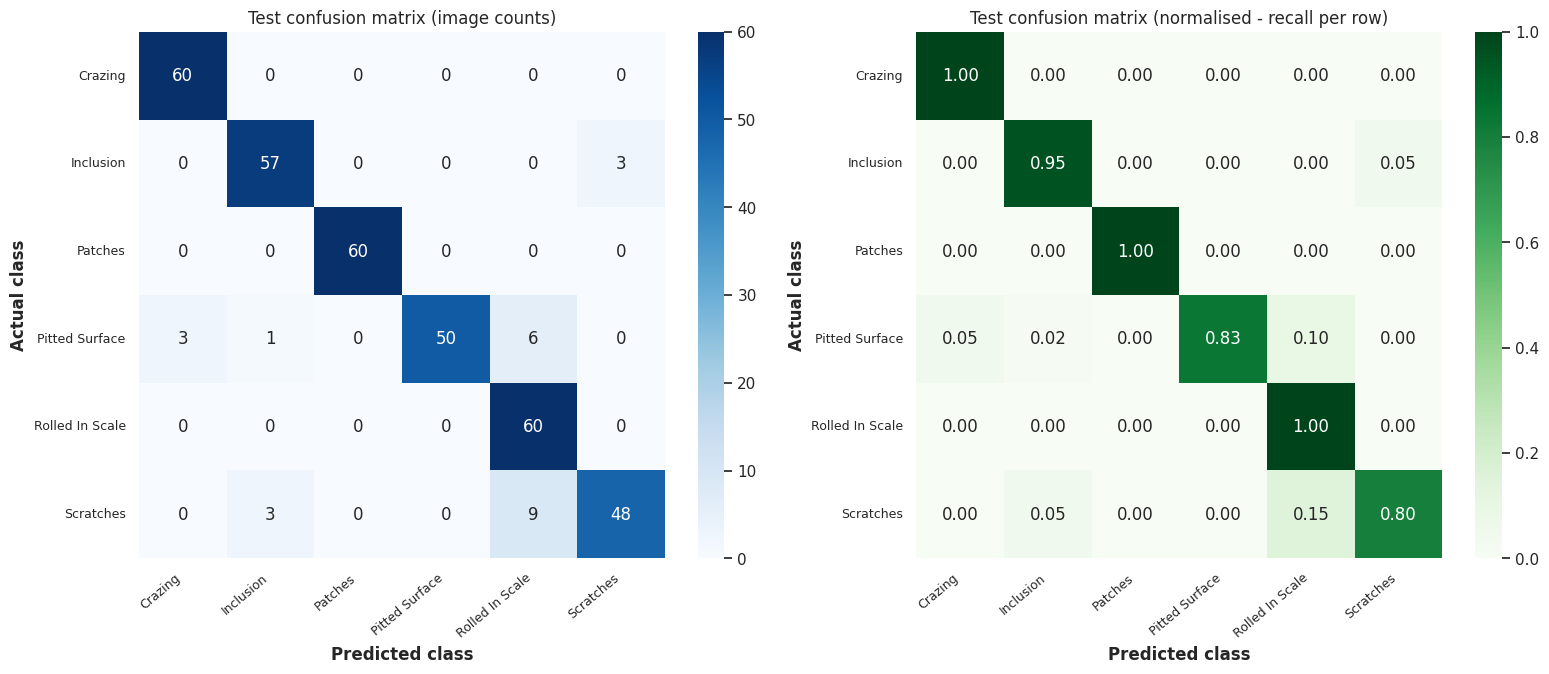

PER-CLASS TEST ACCURACY (recall)
Crazing            100.00%  ############################## (60 images)
Inclusion          95.00%  ############################ (60 images)
Patches            100.00%  ############################## (60 images)
Pitted Surface     83.33%  ######################### (60 images)
Rolled In Scale    100.00%  ############################## (60 images)
Scratches          80.00%  ######################## (60 images)

MOST COMMON CONFUSIONS ON THE TEST SET
  9 x  Scratches  ->  predicted as  Rolled In Scale
  6 x  Pitted Surface  ->  predicted as  Rolled In Scale
  3 x  Scratches  ->  predicted as  Inclusion
  3 x  Pitted Surface  ->  predicted as  Crazing
  3 x  Inclusion  ->  predicted as  Scratches
  1 x  Pitted Surface  ->  predicted as  Inclusion


In [ ]:
# ------------------------------------------------------------------
# Test-set confusion matrices - raw counts and row-normalised
# ------------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)
cm_normalised = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, (ax_counts, ax_norm) = plt.subplots(1, 2, figsize=(16, 6.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", square=True, cbar=True,
            xticklabels=pretty_labels, yticklabels=pretty_labels, ax=ax_counts)
ax_counts.set_xlabel("Predicted class", fontweight="bold")
ax_counts.set_ylabel("Actual class", fontweight="bold")
ax_counts.set_title("Test confusion matrix (image counts)")

sns.heatmap(cm_normalised, annot=True, fmt=".2f", cmap="Greens", square=True,
            cbar=True, vmin=0, vmax=1,
            xticklabels=pretty_labels, yticklabels=pretty_labels, ax=ax_norm)
ax_norm.set_xlabel("Predicted class", fontweight="bold")
ax_norm.set_ylabel("Actual class", fontweight="bold")
ax_norm.set_title("Test confusion matrix (normalised - recall per row)")

for ax in (ax_counts, ax_norm):
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
save_fig(fig, "07_test_confusion_matrix.png")
plt.show()

print("=" * 66)
print("PER-CLASS TEST ACCURACY (recall)")
print("=" * 66)
per_class_recall = cm.diagonal() / cm.sum(axis=1)
for name, value, support in zip(pretty_labels, per_class_recall, cm.sum(axis=1)):
    bar = "#" * int(value * 30)
    print(f"{name:<18} {value:6.2%}  {bar} ({int(support)} images)")

print("\n" + "=" * 66)
print("MOST COMMON CONFUSIONS ON THE TEST SET")
print("=" * 66)
confusions = [(cm[i, j], pretty_labels[i], pretty_labels[j])
              for i in range(NUM_CLASSES) for j in range(NUM_CLASSES)
              if i != j and cm[i, j] > 0]
if confusions:
    for count, actual, predicted in sorted(confusions, reverse=True)[:8]:
        print(f"{count:3d} x  {actual}  ->  predicted as  {predicted}")
else:
    print("No misclassifications on this test set.")

Saved plot -> artifacts/plots/08_test_per_class_metrics.png


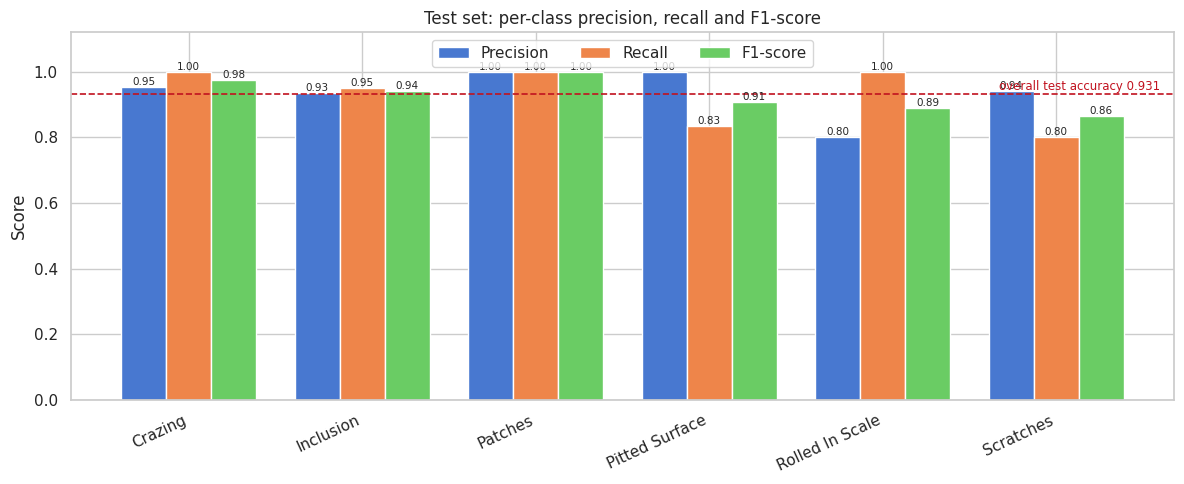

Strongest class : Patches (F1 = 1.0000)
Weakest class   : Scratches (F1 = 0.8649)

The weakest class is where additional training images would pay off most.


In [ ]:
# ------------------------------------------------------------------
# Per-class precision / recall / F1 on the test set
# ------------------------------------------------------------------

precision_per, recall_per, f1_per, support_per = precision_recall_fscore_support(
    y_true, y_pred, zero_division=0)

x_pos = np.arange(NUM_CLASSES)
width = 0.26

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - width, precision_per, width, label="Precision")
ax.bar(x_pos, recall_per, width, label="Recall")
ax.bar(x_pos + width, f1_per, width, label="F1-score")

for i in range(NUM_CLASSES):
    for offset, value in zip((-width, 0, width),
                             (precision_per[i], recall_per[i], f1_per[i])):
        ax.text(i + offset, value, f"{value:.2f}", ha="center", va="bottom",
                fontsize=7.5)

ax.axhline(test_accuracy, color="#c1121f", linestyle="--", lw=1.2)
ax.text(NUM_CLASSES - 0.4, test_accuracy + 0.015,
        f"overall test accuracy {test_accuracy:.3f}",
        color="#c1121f", fontsize=8.5, ha="right")
ax.set_xticks(x_pos)
ax.set_xticklabels(pretty_labels, rotation=25, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Test set: per-class precision, recall and F1-score")
ax.legend(ncol=3, loc="upper center")

plt.tight_layout()
save_fig(fig, "08_test_per_class_metrics.png")
plt.show()

weakest = int(np.argmin(f1_per))
strongest = int(np.argmax(f1_per))
print(f"Strongest class : {pretty_labels[strongest]} (F1 = {f1_per[strongest]:.4f})")
print(f"Weakest class   : {pretty_labels[weakest]} (F1 = {f1_per[weakest]:.4f})")
print("\nThe weakest class is where additional training images would pay off most.")

---
## 12. Export Model and Evaluation Artifacts

Task 2a exported a `joblib` pipeline plus JSON metrics and a manifest. The deep-learning
equivalent saves:

| Artifact | Path | Contents |
|---|---|---|
| Selected model | `artifacts/model/steel_defect_classifier.keras` | Architecture, weights and preprocessing in one file |
| Test metrics | `artifacts/metrics/test_metrics.json` | The reported result, overall and per class |
| Validation comparison | `artifacts/metrics/validation_model_comparison.json` | How the model was selected (written in Section 10) |
| Training history | `artifacts/metrics/training_history.json` | Per-epoch accuracy and loss |
| Classification report | `artifacts/metrics/test_classification_report.csv` | The per-class table as CSV |
| Confusion matrix | `artifacts/metrics/test_confusion_matrix.csv` | Raw counts |
| Split manifest | `artifacts/metadata/split_manifest.json` | Exact composition of each split |
| Model metadata | `artifacts/metadata/model_metadata.json` | Architecture, class mapping, image size, seed, final test metrics |
| Plots | `artifacts/plots/*.png` | Every figure produced during this run |

The **`.keras` format** is the modern Keras 3 single-file format, replacing older HDF5
(`.h5`) and `SavedModel` directory formats. Because augmentation and normalisation are
layers inside the graph, this one file is genuinely all that is needed to make predictions
elsewhere — nothing about the preprocessing has to be remembered and reimplemented.

Saving the **class/index mapping** in the metadata is what guarantees that output index `4`
still means `rolled-in_scale` when the model is reloaded months later. The **split manifest**
records exactly which images landed in which split, so the experiment can be reproduced or
audited later.

> All values written below are computed in this run. Nothing is hard-coded.

In [ ]:
# ------------------------------------------------------------------
# Save the selected model and all evaluation artifacts
# ------------------------------------------------------------------

MODEL_PATH = MODEL_DIR / "steel_defect_classifier.keras"
TEST_METRICS_PATH = METRICS_DIR / "test_metrics.json"
HISTORY_PATH = METRICS_DIR / "training_history.json"
REPORT_PATH = METRICS_DIR / "test_classification_report.csv"
CONFUSION_PATH = METRICS_DIR / "test_confusion_matrix.csv"
METADATA_PATH = METADATA_DIR / "model_metadata.json"
SPLIT_MANIFEST_PATH = METADATA_DIR / "split_manifest.json"

# --- the selected model, saved under its final production name ---
selected_model.save(MODEL_PATH)

# --- final test metrics: the reported result ---
test_metrics = {
    "split": "test",
    "source": "data/test (copied from NEU-DET/validation/images)",
    "selected_model": SELECTED_MODEL_NAME,
    "accuracy": float(test_accuracy),
    "loss": float(test_loss),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "precision_weighted": float(precision_weighted),
    "recall_weighted": float(recall_weighted),
    "f1_weighted": float(f1_weighted),
    "n_test_images": int(len(y_true)),
    "n_correct": int((y_true == y_pred).sum()),
    "validation_accuracy_of_selected_model": selected_val_accuracy,
    "per_class": {
        DISPLAY_NAMES[name]: {
            "precision": float(precision_per[i]),
            "recall": float(recall_per[i]),
            "f1": float(f1_per[i]),
            "support": int(support_per[i]),
        }
        for i, name in enumerate(CLASS_NAMES)
    },
    "evaluated_at_utc": datetime.now(timezone.utc).isoformat(),
}
TEST_METRICS_PATH.write_text(json.dumps(test_metrics, indent=2))

# --- per-epoch training history ---
HISTORY_PATH.write_text(json.dumps(
    {key: [float(v) for v in values] for key, values in full_history.items()},
    indent=2,
))

# --- tabular reports ---
report_df.to_csv(REPORT_PATH)
pd.DataFrame(cm, index=pretty_labels, columns=pretty_labels).to_csv(CONFUSION_PATH)

# --- split manifest: exactly which files went where ---
split_manifest = {
    "random_state": int(RANDOM_STATE),
    "validation_fraction": float(VALIDATION_FRACTION),
    "strategy": {
        "train": "80% of NEU-DET/train/images, stratified per class",
        "validation": "20% of NEU-DET/train/images, stratified per class",
        "test": "all of NEU-DET/validation/images, copied unchanged",
    },
    "counts": {"train": int(n_train), "validation": int(n_val),
               "test": int(n_test), "total": int(n_total)},
    "per_class_counts": {
        DISPLAY_NAMES[c]: {
            "train": len(train_catalogue[c]),
            "validation": len(validation_catalogue[c]),
            "test": len(test_catalogue[c]),
        } for c in CLASS_NAMES
    },
    "files": {
        split: {cls: sorted(p.name for p in files)
                for cls, files in catalogue.items()}
        for split, catalogue in split_catalogues.items()
    },
    "leakage_checks": "passed - no shared filenames or content hashes across splits",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
}
SPLIT_MANIFEST_PATH.write_text(json.dumps(split_manifest, indent=2))

# --- metadata / manifest ---
model_metadata = {
    "model_name": "steel_defect_classifier",
    "model_version": "2.0.0-train-val-test",
    "task": "image classification - steel surface defect type",
    "architecture": BACKBONE,
    "selected_stage": SELECTED_MODEL_NAME,
    "framework": f"tensorflow {tf.__version__} / keras {keras.__version__}",
    "pretrained_weights": "imagenet",
    "fine_tuning_run": bool(history_fine is not None),
    "fine_tune_from_layer": int(FINE_TUNE_AT) if history_fine is not None else None,
    "class_names": CLASS_NAMES,
    "class_index_map": CLASS_INDEX_MAP,
    "display_names": DISPLAY_NAMES,
    "num_classes": int(NUM_CLASSES),
    "image_size": list(IMG_SIZE),
    "input_shape": list(IMG_SHAPE),
    "batch_size": int(BATCH_SIZE),
    "random_state": int(RANDOM_STATE),
    "preprocessing": (
        "resize to 224x224, grayscale->RGB; normalisation is a layer inside "
        "the model, so no external preprocessing is required at inference"
    ),
    "augmentation": "training split only (flip, rotation, zoom, translation, contrast)",
    "epochs_trained": int(len(full_history["accuracy"])),
    "split_counts": {"train": int(n_train), "validation": int(n_val),
                     "test": int(n_test)},
    "dataset": "NEU Surface Defect Database (NEU-DET)",
    "final_test_metrics": {
        "accuracy": float(test_accuracy),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
    },
    "artifact_paths": {
        "model": str(MODEL_PATH.relative_to(PROJECT_ROOT)),
        "test_metrics": str(TEST_METRICS_PATH.relative_to(PROJECT_ROOT)),
        "validation_comparison": str(VAL_COMPARISON_PATH.relative_to(PROJECT_ROOT)),
        "history": str(HISTORY_PATH.relative_to(PROJECT_ROOT)),
        "classification_report": str(REPORT_PATH.relative_to(PROJECT_ROOT)),
        "confusion_matrix": str(CONFUSION_PATH.relative_to(PROJECT_ROOT)),
        "split_manifest": str(SPLIT_MANIFEST_PATH.relative_to(PROJECT_ROOT)),
    },
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
}
METADATA_PATH.write_text(json.dumps(model_metadata, indent=2))

print("Artifacts saved:")
for path in [MODEL_PATH, TEST_METRICS_PATH, VAL_COMPARISON_PATH, HISTORY_PATH,
             REPORT_PATH, CONFUSION_PATH, METADATA_PATH, SPLIT_MANIFEST_PATH]:
    print(f"  - {str(path.relative_to(PROJECT_ROOT)):<56} "
          f"{path.stat().st_size / 1024:8.1f} KB")

print("\nPlots saved:")
for path in sorted(PLOTS_DIR.glob("*.png")):
    print(f"  - {path.relative_to(PROJECT_ROOT)}")

Artifacts saved:
  - artifacts/model/steel_defect_classifier.keras             32676.1 KB
  - artifacts/metrics/test_metrics.json                           1.4 KB
  - artifacts/metrics/validation_model_comparison.json            0.7 KB
  - artifacts/metrics/training_history.json                       3.6 KB
  - artifacts/metrics/test_classification_report.csv              0.3 KB
  - artifacts/metrics/test_confusion_matrix.csv                   0.2 KB
  - artifacts/metadata/model_metadata.json                        2.1 KB
  - artifacts/metadata/split_manifest.json                       54.1 KB

Plots saved:
  - artifacts/plots/01_split_distribution.png
  - artifacts/plots/02_split_proportions.png
  - artifacts/plots/03_class_examples.png
  - artifacts/plots/04_train_class_distribution.png
  - artifacts/plots/05_augmentation_examples.png
  - artifacts/plots/06_training_curves.png
  - artifacts/plots/07_test_confusion_matrix.png
  - artifacts/plots/08_test_per_class_metrics.png


---
## 13. Inference on New / Unseen Images

### Training vs inference — the critical distinction

This mirrors the historical-vs-incoming split from Task 2a. There, historical rows carried a
known `readmission_30d` label while incoming patients did not. Here, training images live in
a folder that names their defect, while a new image arriving from a factory camera carries
no label at all.

```
TRAINING                              INFERENCE
--------                              ---------
Labeled training images               New steel surface image
       ↓                                     ↓
Deep-learning training                Same preprocessing
       ↓                                     ↓
Saved .keras model          ───────►  Load saved .keras model
                                             ↓
                                      Defect prediction
```

| | Training images | New / unseen images |
|---|---|---|
| **When** | Collected and labelled in advance | Captured now, on the line |
| **Has label?** | Yes — the folder name | **No** — the defect type is what we want to know |
| **Purpose** | Learn what each defect looks like | Generate a prediction to act on |
| **Preprocessing** | Resize, RGB, normalise | **Exactly the same** |

### Loading the frozen artifact

The cell below **reloads the model from disk** rather than continuing to use the in-memory
`selected_model` object. This is the single most important habit this section teaches: in
production the training notebook is not running, and the scoring service has nothing but the
saved file. Reloading here proves the artifact is genuinely self-sufficient — if
preprocessing had been applied outside the model, or the class order had not been recorded,
this is exactly where it would break.

In [ ]:
# ------------------------------------------------------------------
# Reload the saved artifact - simulating a fresh inference environment
# ------------------------------------------------------------------
# In production this code would live in a separate script or service, not in
# the training notebook. Nothing below refers to `model` or `selected_model`.

loaded_model = keras.models.load_model(MODEL_PATH)
loaded_metadata = json.loads(METADATA_PATH.read_text())

INFERENCE_CLASS_NAMES = loaded_metadata["class_names"]
INFERENCE_DISPLAY_NAMES = loaded_metadata["display_names"]
INFERENCE_IMG_SIZE = tuple(loaded_metadata["image_size"])

print("Model reloaded from disk (no retraining).")
print(f"  Path          : {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"  Architecture  : {loaded_metadata['architecture']}")
print(f"  Selected stage: {loaded_metadata['selected_stage']}")
print(f"  Classes       : {INFERENCE_CLASS_NAMES}")
print(f"  Image size    : {INFERENCE_IMG_SIZE}")
print(f"  Test accuracy : "
      f"{loaded_metadata['final_test_metrics']['accuracy']:.4f}")
print(f"  Trained at    : {loaded_metadata['created_at_utc']}")

# Confirm the reloaded model behaves identically to the in-memory one.
check_batch = next(iter(test_ds))[0][:8]
if np.allclose(selected_model.predict(check_batch, verbose=0),
               loaded_model.predict(check_batch, verbose=0), atol=1e-5):
    print("\nVerified: the reloaded model reproduces the selected model exactly.")
else:
    print("\nWARNING: reloaded predictions differ from the in-memory model.")

Model reloaded from disk (no retraining).
  Path          : artifacts/model/steel_defect_classifier.keras
  Architecture  : EfficientNetB0
  Selected stage: Stage 2 (fine-tuned)
  Classes       : ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
  Image size    : (224, 224)
  Test accuracy : 0.9306
  Trained at    : 2026-09-18T02:32:08.837709+00:00

Verified: the reloaded model reproduces the selected model exactly.


In [ ]:
# ------------------------------------------------------------------
# The production inference function
# ------------------------------------------------------------------

def predict_defect(image_path, model=None, verbose: bool = True) -> dict:
    """Classify a single steel surface image using the saved model artifact.

    Args:
        image_path: Path to an image file (.bmp, .jpg, .png ...).
        model: Trained Keras model. Defaults to the artifact reloaded from disk.
        verbose: Print a formatted inspection report as well as returning it.

    Returns:
        dict with predicted_class, predicted_label, confidence,
        confidence_percent and all_probabilities.
    """
    if model is None:
        model = loaded_model      # the artifact, not the training-time object

    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(
            f"No image found at: {image_path}\n"
            "The path must point at an image file, not a folder."
        )

    # Identical preprocessing to training: resize, force RGB, keep raw 0-255.
    # Normalisation happens inside the model, so it must NOT be repeated here.
    img = keras.utils.load_img(image_path, target_size=INFERENCE_IMG_SIZE,
                               color_mode="rgb")
    batch = np.expand_dims(keras.utils.img_to_array(img), axis=0)

    probabilities = model.predict(batch, verbose=0)[0]
    best_idx = int(np.argmax(probabilities))
    predicted_class = INFERENCE_CLASS_NAMES[best_idx]

    result = {
        "image_name": image_path.name,
        "predicted_class": predicted_class,
        "predicted_label": INFERENCE_DISPLAY_NAMES[predicted_class],
        "confidence": float(probabilities[best_idx]),
        "confidence_percent": float(probabilities[best_idx] * 100),
        "all_probabilities": {
            INFERENCE_DISPLAY_NAMES[name]: float(prob)
            for name, prob in zip(INFERENCE_CLASS_NAMES, probabilities)
        },
    }

    if verbose:
        print("=" * 52)
        print(f"Image            : {result['image_name']}")
        print("-" * 52)
        print(f"Predicted Defect : {result['predicted_label']}")
        print(f"Confidence       : {result['confidence_percent']:.2f}%")
        print("-" * 52)
        print("All class probabilities:")
        for label, prob in sorted(result["all_probabilities"].items(),
                                  key=lambda kv: kv[1], reverse=True):
            print(f"   {label:<18} {prob * 100:6.2f}%  {'#' * int(prob * 32)}")
        print("=" * 52)

    return result


# --- Demonstrate on one test image ---
demo_path = test_catalogue[CLASS_NAMES[0]][0]
_ = predict_defect(demo_path)

Image            : crazing_241.jpg
----------------------------------------------------
Predicted Defect : Crazing
Confidence       : 99.86%
----------------------------------------------------
All class probabilities:
   Crazing             99.86%  ###############################
   Patches              0.10%  
   Pitted Surface       0.03%  
   Rolled In Scale      0.00%  
   Inclusion            0.00%  
   Scratches            0.00%  


In [ ]:
# ------------------------------------------------------------------
# Batch inference on a sample of unseen test images
# ------------------------------------------------------------------
# These images were never used for training, early stopping or model selection.
# The actual label is known here only so we can show whether each prediction
# was right - a real incoming image would have no label at all.

N_SAMPLES = 12

# Rebuild the ordered test file list (same order as test_ds).
test_file_paths = []
for class_name in CLASS_NAMES:
    test_file_paths.extend(test_catalogue[class_name])

assert len(test_file_paths) == len(y_true), (
    f"{len(test_file_paths)} files but {len(y_true)} predictions - "
    "file listing and dataset order disagree."
)

rng = np.random.default_rng(RANDOM_STATE)
sample_positions = rng.choice(len(test_file_paths),
                              size=min(N_SAMPLES, len(test_file_paths)),
                              replace=False)

inference_records = []
for pos in sample_positions:
    path = test_file_paths[pos]
    actual_class = path.parent.name
    outcome = predict_defect(path, verbose=False)
    inference_records.append({
        "image_name": outcome["image_name"],
        "actual_class": actual_class,
        "predicted_class": outcome["predicted_class"],
        "confidence": round(outcome["confidence"], 4),
        "correct": actual_class == outcome["predicted_class"],
        "_path": path,
    })

inference_df = pd.DataFrame(inference_records).drop(columns=["_path"])
print(f"Ran inference on {len(inference_df)} unseen test images")
print(f"Correct: {int(inference_df['correct'].sum())} / {len(inference_df)}")
display(inference_df)

Ran inference on 12 unseen test images
Correct: 10 / 12


,image_name,actual_class,predicted_class,confidence,correct
0,patches_275.jpg,patches,patches,0.9986,True
1,crazing_271.jpg,crazing,crazing,0.9889,True
2,rolled-in_scale_271.jpg,rolled-in_scale,rolled-in_scale,0.7051,True
3,pitted_surface_250.jpg,pitted_surface,pitted_surface,0.7824,True
4,pitted_surface_290.jpg,pitted_surface,crazing,0.8050,False
5,scratches_244.jpg,scratches,scratches,0.9724,True
6,crazing_272.jpg,crazing,crazing,0.9992,True
7,patches_273.jpg,patches,patches,1.0000,True
8,crazing_274.jpg,crazing,crazing,0.9968,True
9,rolled-in_scale_249.jpg,rolled-in_scale,rolled-in_scale,0.5629,True


Saved plot -> artifacts/plots/09_test_sample_predictions.png


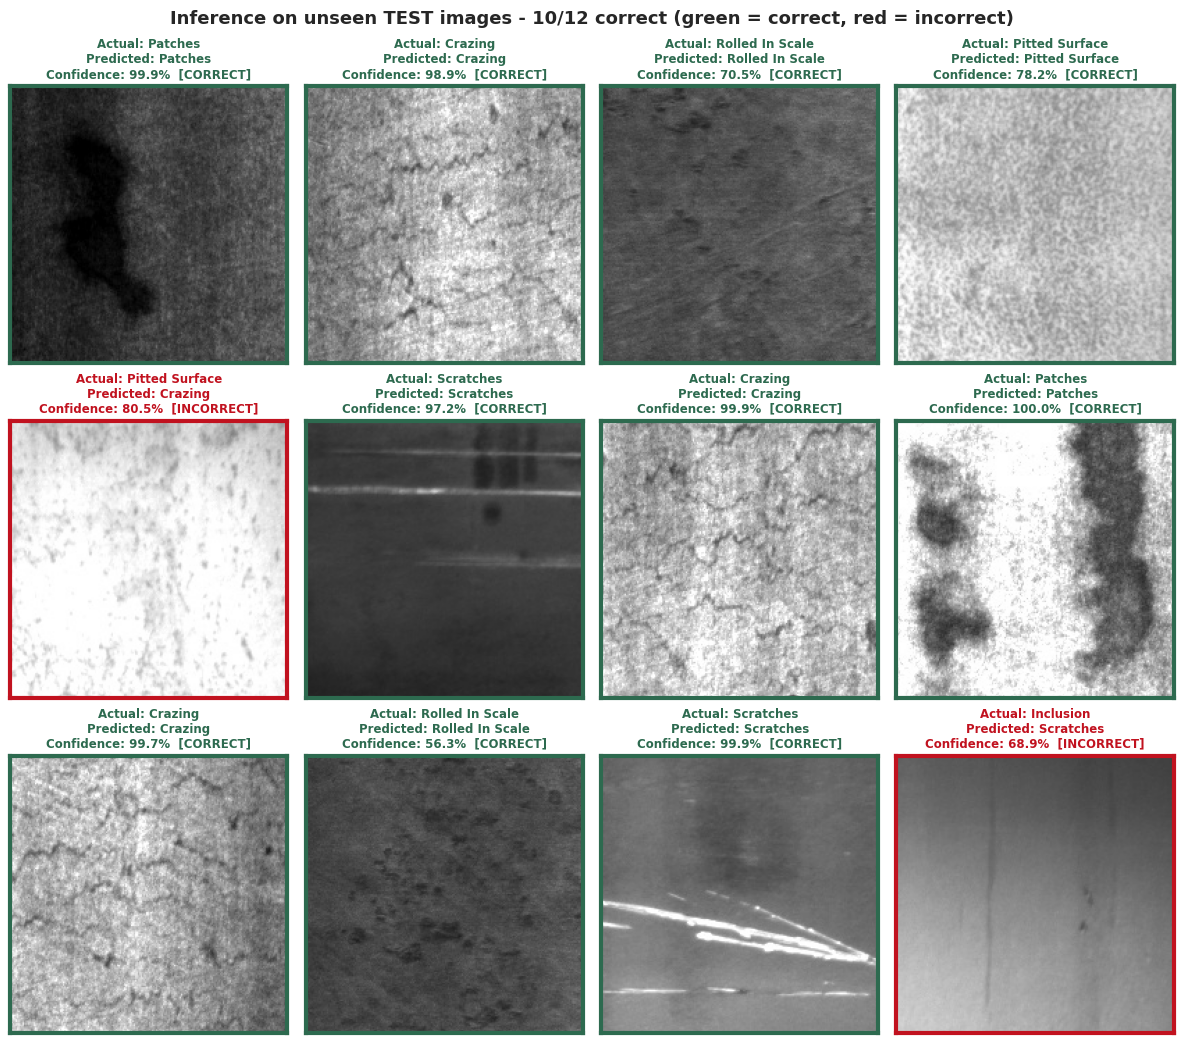

In [ ]:
# ------------------------------------------------------------------
# Visualise the sample predictions
# ------------------------------------------------------------------

n_cols = 4
n_rows = int(np.ceil(len(inference_records) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.0, n_rows * 3.6))
axes = np.atleast_1d(axes).flatten()

for ax in axes:
    ax.axis("off")
    ax.grid(False)

for i, record in enumerate(inference_records):
    ax = axes[i]
    with Image.open(record["_path"]) as img:
        ax.imshow(np.array(img), cmap="gray")

    actual = DISPLAY_NAMES[record["actual_class"]]
    predicted = DISPLAY_NAMES[record["predicted_class"]]
    colour = "#2d6a4f" if record["correct"] else "#c1121f"
    verdict = "CORRECT" if record["correct"] else "INCORRECT"

    ax.set_title(
        f"Actual: {actual}\nPredicted: {predicted}\n"
        f"Confidence: {record['confidence']:.1%}  [{verdict}]",
        fontsize=8.5, color=colour, fontweight="bold", pad=6,
    )
    ax.axis("on")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(colour)
        spine.set_linewidth(3)

n_correct = sum(r["correct"] for r in inference_records)
fig.suptitle(
    f"Inference on unseen TEST images - {n_correct}/{len(inference_records)} "
    "correct (green = correct, red = incorrect)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
save_fig(fig, "09_test_sample_predictions.png")
plt.show()

---
## 14. Save Prediction Results

Task 2a wrote scored incoming patients to `artifacts/predictions/incoming_predictions.csv`.
The same pattern applies here: an inference run produces a table that downstream systems —
a quality dashboard, a coil-tracking database, a shift report — can consume without knowing
anything about TensorFlow.

The `correct` column exists only because these demonstration images come from the labelled
test set. A genuine production scoring run would have no such column, since the true defect
type is exactly what is unknown.

In [ ]:
# ------------------------------------------------------------------
# Persist the sample inference results
# ------------------------------------------------------------------

SAMPLE_PREDICTIONS_PATH = PREDICTIONS_DIR / "sample_predictions.csv"

predictions_output = inference_df[
    ["image_name", "actual_class", "predicted_class", "confidence", "correct"]
].copy()
predictions_output.to_csv(SAMPLE_PREDICTIONS_PATH, index=False)

print(f"Predictions saved to: "
      f"{SAMPLE_PREDICTIONS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Rows written        : {len(predictions_output)}")
print(f"\nAccuracy on this sample: {predictions_output['correct'].mean():.2%}")
print("\nPrediction counts by class:")
display(predictions_output["predicted_class"].value_counts())

print("\nSaved file preview:")
display(pd.read_csv(SAMPLE_PREDICTIONS_PATH).head(10))

Predictions saved to: artifacts/predictions/sample_predictions.csv
Rows written        : 12

Accuracy on this sample: 83.33%

Prediction counts by class:


,count
predicted_class,
crazing,4
scratches,3
patches,2
rolled-in_scale,2
pitted_surface,1



Saved file preview:


,image_name,actual_class,predicted_class,confidence,correct
0,patches_275.jpg,patches,patches,0.9986,True
1,crazing_271.jpg,crazing,crazing,0.9889,True
2,rolled-in_scale_271.jpg,rolled-in_scale,rolled-in_scale,0.7051,True
3,pitted_surface_250.jpg,pitted_surface,pitted_surface,0.7824,True
4,pitted_surface_290.jpg,pitted_surface,crazing,0.8050,False
5,scratches_244.jpg,scratches,scratches,0.9724,True
6,crazing_272.jpg,crazing,crazing,0.9992,True
7,patches_273.jpg,patches,patches,1.0000,True
8,crazing_274.jpg,crazing,crazing,0.9968,True
9,rolled-in_scale_249.jpg,rolled-in_scale,rolled-in_scale,0.5629,True


In [ ]:
# ------------------------------------------------------------------
# Full test-set predictions (every image, not just the sample)
# ------------------------------------------------------------------
# A complete record of the final evaluation, useful for error analysis.

TEST_PREDICTIONS_PATH = PREDICTIONS_DIR / "test_predictions.csv"

test_predictions = pd.DataFrame({
    "image_name": [p.name for p in test_file_paths],
    "actual_class": [CLASS_NAMES[i] for i in y_true],
    "predicted_class": [CLASS_NAMES[i] for i in y_pred],
    "confidence": np.round(y_confidence, 4),
    "correct": y_true == y_pred,
})

# One column per class probability, for threshold analysis later.
for idx, class_name in enumerate(CLASS_NAMES):
    test_predictions[f"prob_{class_name}"] = np.round(y_prob[:, idx], 4)

test_predictions.to_csv(TEST_PREDICTIONS_PATH, index=False)

print(f"Full test predictions saved to: "
      f"{TEST_PREDICTIONS_PATH.relative_to(PROJECT_ROOT)}")
print(f"Rows: {len(test_predictions)}  |  "
      f"Accuracy: {test_predictions['correct'].mean():.2%}")
display(test_predictions.head())

Full test predictions saved to: artifacts/predictions/test_predictions.csv
Rows: 360  |  Accuracy: 93.06%


,image_name,actual_class,predicted_class,confidence,correct,prob_crazing,prob_inclusion,prob_patches,prob_pitted_surface,prob_rolled-in_scale,prob_scratches
0,crazing_241.jpg,crazing,crazing,0.9999,True,0.9999,0.0000,0.0000,0.0000,0.0000,0.0
1,crazing_242.jpg,crazing,crazing,0.9996,True,0.9996,0.0000,0.0000,0.0000,0.0003,0.0
2,crazing_243.jpg,crazing,crazing,0.9999,True,0.9999,0.0000,0.0000,0.0000,0.0001,0.0
3,crazing_244.jpg,crazing,crazing,0.9986,True,0.9986,0.0000,0.0001,0.0000,0.0013,0.0
4,crazing_245.jpg,crazing,crazing,0.9994,True,0.9994,0.0001,0.0002,0.0001,0.0003,0.0


---
## 15. Gradio Deployment Demo

A trained model sitting in a notebook is not a deployed model. Gradio wraps the saved
artifact in a web interface that runs directly inside Colab, so someone with no Python
knowledge can drag an image in and read the result.

```
Upload steel image
       ↓
Preprocessing (resize, RGB)
       ↓
Saved .keras model          ← loaded from artifacts/model/, never retrained
       ↓
Six-class probability distribution
       ↓
Predicted defect + confidence
```

The app uses **`loaded_model`** — the artifact reloaded from disk in Section 13. It performs
no training. This is what a thin deployment layer looks like: load the frozen model once at
startup, then serve predictions.

A **confidence threshold** is included as well. Below it, the app recommends manual review
rather than pretending to be certain — which is how an inspection aid should behave:
confident where it can be, deferential where it cannot.

> **Running it:** execute both cells. Gradio prints a local URL and a public
> `*.gradio.live` link that stays active for 72 hours, so the app can be demonstrated on
> another machine. Stop it with `demo.close()` or by interrupting the cell.

In [ ]:
# Gradio is not part of the Colab base image.
%pip install -q gradio

import gradio as gr
print(f"Gradio version: {gr.__version__}")

Gradio version: 6.26.0


In [ ]:
# ------------------------------------------------------------------
# Steel Surface Defect Inspector - Gradio application
# ------------------------------------------------------------------
# This is a deployment layer over the SAVED artifact. It does not train.

CONFIDENCE_THRESHOLD = 0.70      # below this, recommend manual review

DEFECT_NOTES = {
    "crazing": "A network of fine hairline cracks across the surface.",
    "inclusion": "Foreign material rolled into the steel, usually dark and elongated.",
    "patches": "Irregular discoloured regions with diffuse edges.",
    "pitted_surface": "Clusters of small cavities and pockmarks.",
    "rolled-in_scale": "Oxide scale pressed into the metal during rolling.",
    "scratches": "Long, straight, directional gouges in the surface.",
}


def classify_steel_surface(image):
    """Gradio callback: a PIL image in, (label dict, markdown report) out."""
    if image is None:
        return {}, "### Upload a steel surface image to begin."

    # Identical preprocessing to training: RGB, resized, raw 0-255.
    # Normalisation lives inside the model, so it is not repeated here.
    pil_image = image.convert("RGB").resize(INFERENCE_IMG_SIZE)
    batch = np.expand_dims(keras.utils.img_to_array(pil_image), axis=0)

    probabilities = loaded_model.predict(batch, verbose=0)[0]
    best_idx = int(np.argmax(probabilities))
    predicted_class = INFERENCE_CLASS_NAMES[best_idx]
    predicted_label = INFERENCE_DISPLAY_NAMES[predicted_class]
    confidence = float(probabilities[best_idx])

    # gr.Label renders this dict as a ranked confidence bar chart.
    label_output = {
        INFERENCE_DISPLAY_NAMES[name]: float(prob)
        for name, prob in zip(INFERENCE_CLASS_NAMES, probabilities)
    }

    if confidence >= CONFIDENCE_THRESHOLD:
        status = "PASS - high confidence"
        advice = ("Confidence is above the review threshold, so this "
                  "classification can be logged automatically.")
    else:
        status = "REVIEW - low confidence"
        advice = (f"Confidence is below the {CONFIDENCE_THRESHOLD:.0%} threshold. "
                  "Route this image to a human inspector before acting on it.")

    ranked = sorted(zip(INFERENCE_CLASS_NAMES, probabilities),
                    key=lambda kv: kv[1], reverse=True)
    table_rows = "\n".join(
        f"| {INFERENCE_DISPLAY_NAMES[name]} | {prob * 100:.2f}% |"
        for name, prob in ranked
    )

    report = f"""
## Predicted Defect: {predicted_label}
## Confidence: {confidence * 100:.1f}%

**Status:** {status}

{DEFECT_NOTES.get(predicted_class, "")}

{advice}

### All class probabilities

| Defect category | Probability |
|---|---|
{table_rows}
"""
    return label_output, report


# --- One real example image per class, taken from the test split ---
example_images = [[str(test_catalogue[c][0])] for c in CLASS_NAMES
                  if test_catalogue.get(c)]

with gr.Blocks(title="Steel Surface Defect Inspector",
               theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        """
        # Steel Surface Defect Inspector
        ### Automated quality inspection for hot-rolled steel strip

        Upload a steel surface image and the model classifies it into one of six
        defect categories, with a confidence score for each.

        *Classroom prototype built with transfer learning on the NEU Surface
        Defect Database.*
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="pil", label="Steel surface image",
                                   height=320)
            analyse_button = gr.Button("Analyse surface", variant="primary",
                                       size="lg")
            clear_button = gr.ClearButton(value="Clear")
        with gr.Column(scale=1):
            label_output = gr.Label(num_top_classes=NUM_CLASSES,
                                    label="Confidence by defect category")

    report_output = gr.Markdown()

    if example_images:
        gr.Examples(
            examples=example_images,
            inputs=image_input,
            label="Example images (one per defect class, from the test split)",
        )

    gr.Markdown(
        f"""
        ---
        **Model:** {loaded_metadata['architecture']} ·
        **Artifact:** `{loaded_metadata['artifact_paths']['model']}` ·
        **Test accuracy:** {loaded_metadata['final_test_metrics']['accuracy']:.1%} ·
        **Review threshold:** {CONFIDENCE_THRESHOLD:.0%}

        *Decision-support prototype. Low-confidence results should be confirmed
        by a qualified inspector.*
        """
    )

    analyse_button.click(fn=classify_steel_surface, inputs=image_input,
                         outputs=[label_output, report_output])
    image_input.change(fn=classify_steel_surface, inputs=image_input,
                       outputs=[label_output, report_output])
    clear_button.add([image_input, label_output, report_output])

# share=True produces a public link that stays live for 72 hours.
demo.launch(share=True, debug=False)

/tmp/ipykernel_1408/1922610099.py:79: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Steel Surface Defect Inspector",


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2209b2e39d881bf032.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 16. Manufacturing Use Case

```
Factory inspection camera
          ↓
   Steel surface image
          ↓
 Deep-learning classifier
          ↓
    Defect category
          ↓
 Quality-control review
```

### How this would run on a line

In a production installation, **line-scan cameras** mounted above the strip capture the
surface continuously as it passes, typically under controlled lighting — consistent
illumination is what makes the imagery comparable frame to frame. Frames stream to an
industrial PC or edge device where the model runs inference in milliseconds, so decisions
happen at line speed rather than in a batch job hours later.

The classification then drives a quality-control decision:

| Model output | Quality-control action |
|---|---|
| High-confidence defect | Flag the coil position, log the defect type, alert the operator |
| High-confidence clean surface | Log and continue, no intervention |
| Low confidence | Route the image to a human inspector for a decision |
| Repeated defects of one type | Raise a process alarm — a recurring class points upstream |

That last row is where the real value sits. A single scratch is a quality event; a hundred
scratches in an hour is a **process** problem, and the defect *type* points at the cause.
Rolled-in scale suggests a descaling fault. Repeated inclusions suggest contamination
upstream in the caster. Automatic classification turns inspection from a sorting activity
into a diagnostic feed.

### Advantages over manual inspection

- **Full coverage instead of sampling** — every metre of strip is inspected, not just what
  an inspector happened to be watching.
- **Consistency** — the model applies the same decision boundary at 3am as at 9am. It does
  not tire and it does not disagree with itself.
- **Traceability** — every decision is logged with an image, a class and a confidence score,
  producing a quality record that supports customer claims and audits.
- **Earlier intervention** — catching a recurring defect within minutes rather than at the
  end of a coil reduces scrap.

### What this project is, and is not

> **This is a classroom prototype**, not a production system. It demonstrates how computer
> vision *can* support manufacturing quality inspection, using a public research dataset
> captured under controlled laboratory conditions. It has not been validated on real
> production imagery, has no "clean surface" class, and has undergone none of the safety,
> reliability or integration engineering a real inspection installation requires. Section 17
> sets out the gaps in detail.

Framed properly, the goal is **decision support**, not the unsupervised replacement of
inspectors. The confidence threshold in Section 15 is the mechanism: the model commits when
it is sure and defers when it is not. Deployed responsibly, such a system takes volume off
inspectors rather than authority away from them.

---
## 17. Limitations and Future Improvements

An honest reading of what this model can and cannot do.

### Limitations

**Limited number of images.** A few hundred images per class is modest for deep learning.
Transfer learning and augmentation compensate considerably, but the model has not seen the
full variety of ways a defect can present. Rare presentations will be weaker than the test
score suggests.

**A relatively controlled dataset.** NEU-DET was captured in a laboratory setting:
consistent lighting, fixed camera distance, clean surfaces, tight framing. Every image is
also cropped to roughly 200 × 200 around a defect, which is a far easier input than a raw
camera frame.

**Real-world domain shift.** A working mill has vibration, oil film, water, steam, motion
blur, variable lighting and dust on the lens. Different steel grades, surface finishes,
strip speeds and camera hardware all shift the input distribution. The test accuracy
reported in Section 11 is an unbiased estimate **for this dataset**; it is not a prediction
of performance in a specific plant.

**A small test set.** The test split is unbiased, but it contains only a few hundred images,
so the estimate carries real sampling uncertainty. A few images either way moves the
percentage noticeably, and per-class figures rest on fewer images still.

**Image-level classification does not identify defect location.** The model answers "what
kind of defect is in this image?", not "where is it and how large?". A quality engineer
usually needs position and extent to decide whether to scrap a section or downgrade a coil.

**One label per image.** The model assumes exactly one defect type per image. Real surfaces
carry several at once, and a softmax output cannot express "scratches *and* inclusions".

**No "clean surface" class.** Every NEU-DET image contains a defect, so the model has never
seen defect-free steel and will confidently assign a defect class to a perfect surface. On a
real line, most frames are clean — this is the first gap to close.

**No monitoring or retraining strategy.** The notebook produces a model; a production system
needs drift detection, scheduled retraining and a rollback path.

### Future improvements

**Object detection using the XML annotations.** NEU-DET ships bounding-box annotations in
the `annotations/` folders that this notebook deliberately left unread. Training a detector —
YOLO, Faster R-CNN or RetinaNet — on those files would produce defect *location* and *size*
alongside the class, turning a classification into an actionable quality decision. This is
the single most valuable upgrade, and the data for it is already downloaded.

**More diverse factory images.** Images from the actual line, actual cameras and actual
lighting, covering multiple grades and shifts. More production variety would do more for
generalisation than any architectural change.

**Add a "no defect" class**, essential before the model meets a real line.

**Move to multi-label classification** — replace softmax with independent sigmoid outputs so
several defect types can be reported for one image.

**Cross-validation for a tighter estimate.** With a dataset this size, k-fold
cross-validation over the train+validation pool would give a more stable performance
estimate than a single split, at k times the training cost.

**Deliberate robustness testing** under simulated blur, noise, brightness shifts and
occlusion, to find the failure envelope *before* deployment rather than after.

**Explainability.** Grad-CAM heatmaps showing which region drove a prediction give
inspectors a reason to trust — or usefully distrust — a given call, and trust determines
whether a system is actually used.

**Calibrated uncertainty.** Softmax confidence is a crude proxy. Temperature scaling,
MC-dropout or an ensemble would give calibrated probabilities, making the review threshold a
principled setting rather than a guess.

**Edge optimisation.** TensorFlow Lite or TensorRT conversion with INT8 quantisation would
cut latency and memory for deployment on inline hardware.

**Production monitoring and retraining.** Track the input distribution and per-class
confidence over time, alert on drift, and retrain on a schedule with newly labelled
production images.

---
## 18. Summary

In this notebook you:

1. Inspected the original **NEU-DET** download without modifying it, validating paths rather than assuming them
2. Created a reproducible **train / validation / test** split — a stratified 80/20 of the original training images, with the original validation folder held back as the test set — and proved programmatically that no image appears in two splits
3. Explored the **six defect classes** using training data only
4. Preprocessed and **augmented** the training split, leaving validation and test with preprocessing alone
5. Built **TensorFlow dataset pipelines** with deterministic ordering for validation and test
6. Built a **transfer-learning model** on an ImageNet-pretrained EfficientNetB0 backbone
7. Trained the classification head with the backbone frozen, then **fine-tuned** the upper layers at a 100× smaller learning rate
8. **Selected between the two candidates on the validation split** — the same discipline Task 2a used to choose between Random Forest and XGBoost
9. Evaluated the selected model **once on the held-out test set**, reporting accuracy, macro precision / recall / F1, per-class metrics, a classification report and confusion matrices
10. Exported the `.keras` model, metrics, plots, split manifest and metadata to `artifacts/`
11. **Reloaded the saved artifact from disk** and ran inference on unseen images
12. Saved prediction results to `artifacts/predictions/`
13. Demonstrated deployment with a **Gradio** web application served by the saved model

### How the three splits were used

| Split | Used for | Never used for |
|---|---|---|
| **Train** | Learning model parameters; the only split that is augmented | Any performance reporting |
| **Validation** | Early stopping, `ReduceLROnPlateau`, choosing between the feature-extraction and fine-tuned models | Learning weights; final reporting |
| **Test** | The single final evaluation in Section 11 | Training, early stopping, hyperparameter or model selection |

The reported performance comes from the **test set**, which was untouched until every
modelling decision had already been made. That is what makes it an unbiased estimate.

### Key takeaway for students

Training and inference are **two separate workflows**. Training produces a frozen model
artifact; inference loads that artifact to classify new images **without retraining**. The
preprocessing must be identical on both sides — which is why this notebook puts resizing and
normalisation *inside* the model graph, so the saved `.keras` file carries its own
preprocessing and the two paths cannot drift apart.

The second lesson is about **honest evaluation**: any data you consult while making a
decision stops being a fair test of that decision. Keeping a genuinely held-out test set is
the cheapest safeguard against fooling yourself.

### How this maps to Task 2a

| Task 2a (tabular) | Task 2b (images) |
|---|---|
| Load historical CSV | Inspect original NEU-DET download |
| Stratified train / validation / test split | Stratified 80/20 split + original validation folder as test |
| Exploratory data analysis | Exploratory image analysis |
| Data cleaning | Resizing, RGB conversion, augmentation |
| Random Forest & XGBoost | Transfer learning on EfficientNetB0 |
| — | Fine-tuning the pretrained backbone |
| Compare models on validation | Compare feature-extraction vs fine-tuned on validation |
| Evaluate winner once on test | Evaluate selected model once on test |
| `joblib` artifact + JSON manifest | `.keras` artifact + JSON metadata + split manifest |
| Score incoming patients | Classify new steel images |
| `incoming_predictions.csv` | `sample_predictions.csv`, `test_predictions.csv` |

### Next steps

- Object detection on the `annotations/` XML files to localise defects, not just name them
- Grad-CAM explainability so inspectors can see *why* a call was made
- A "no defect" class and multi-label outputs for realistic factory frames
- A REST API wrapper around `steel_defect_classifier.keras`
- Drift monitoring and a scheduled retraining pipeline